In [1]:
from astropy.io import fits

import numpy as np
import matplotlib.pyplot as plt

from scipy.io import readsav
from scipy.optimize import curve_fit
from sklearn.decomposition import PCA

from tqdm import tqdm

import tools as t

## Extract data

In [2]:
# load files
path_data = '../data/'
data_spectra = fits.getdata(path_data + 'flux_norm_paq12_6173_lionel_tau1_scalingspatial1_sansrotation.fits')
data_rv = readsav(path_data + 'res_rv_bis_6173_lionel_tau1_scaling1_sansrot.sav')
data_rv.keys()

dict_keys(['rv_gauss', 'rv_correl', 'rv_deriv', 'xbiss', 'ybiss', 'l_true', 'lambd', 'flux_moy'])

data_spectra: matrix with 3686 spectra of 122 elements each \
data_rv: dictionary

In [3]:
c = 3e8  # m/s
# extract data
wl = data_rv['lambd']
rv_ccf = data_rv['rv_correl']
template = data_rv['flux_moy']
times = np.arange(0, len(data_spectra) * 144, 144) / 60 / 24  # time in days
times

array([0.000e+00, 1.000e-01, 2.000e-01, ..., 3.683e+02, 3.684e+02,
       3.685e+02], shape=(3686,))

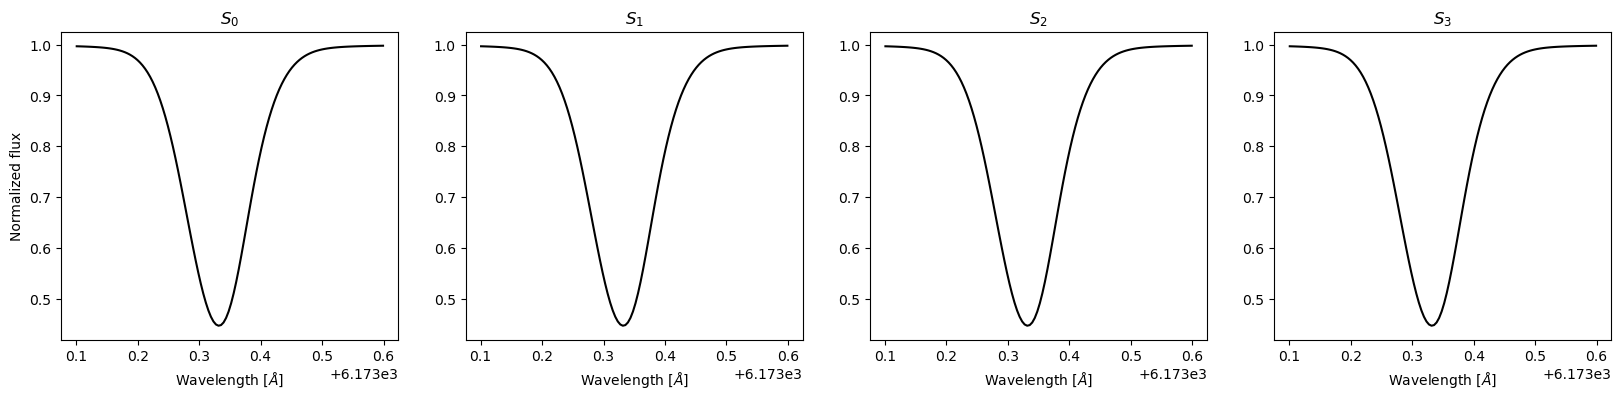

In [4]:
# plot some spectra
n_spectra = 4
fig, axs = plt.subplots(1, n_spectra, figsize=(20, 4))
axs[0].set_ylabel('Normalized flux')
for i in range(n_spectra):
    axs[i].plot(wl, data_spectra[i], color='k')
    axs[i].set_title(f'$S_{i}$')
    axs[i].set_xlabel(r'Wavelength [$\AA$]')
plt.show()

## Calculate RV by template matching

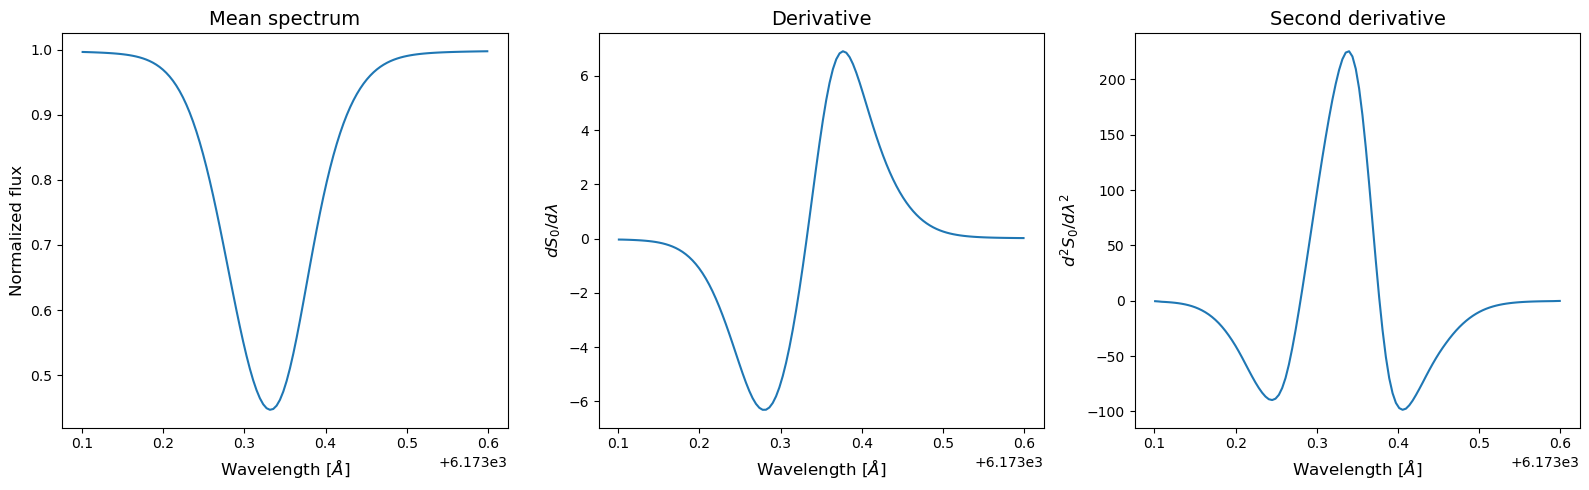

In [5]:
# template matching: calculate the mean spectrum
mean_spec = np.mean(data_spectra, axis=0)
d_S0 = np.gradient(mean_spec, wl)  # derivative of the mean spectrum
d2_S0 = np.gradient(d_S0, wl)  # second derivative of the mean spectrum

fig, axs = plt.subplots(1, 3, figsize=(16, 5))

axs[0].plot(wl, mean_spec)
axs[0].set_title('Mean spectrum', size=14)
axs[0].set_xlabel(r'Wavelength [$\AA$]', size=12)
axs[0].set_ylabel('Normalized flux', size=12)

axs[1].plot(wl, d_S0)
axs[1].set_title('Derivative', size=14)
axs[1].set_xlabel(r'Wavelength [$\AA$]', size=12)
axs[1].set_ylabel(r'$dS_0 / d\lambda$', size=12)

axs[2].plot(wl, d2_S0)
axs[2].set_title('Second derivative', size=14)
axs[2].set_xlabel(r'Wavelength [$\AA$]', size=12)
axs[2].set_ylabel(r'$d^2S_0 / d\lambda^2$', size=12)

fig.tight_layout()
plt.show()

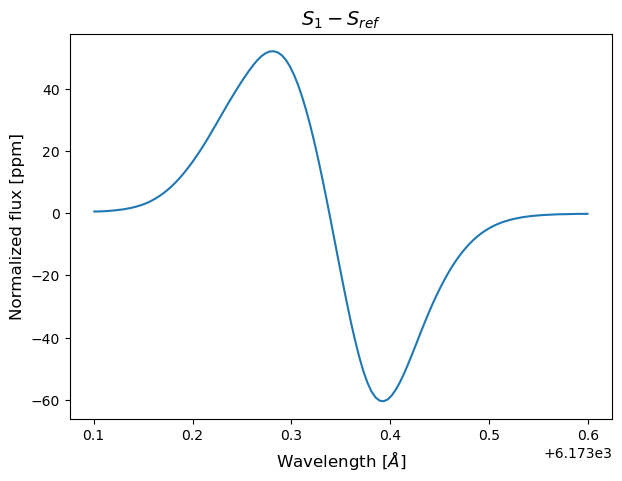

In [6]:
# first spectrum - reference spectrum
# small differences between one spectrum and other
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(wl, (data_spectra[1] - mean_spec) * 10**6)
ax.set_title(r'$S_1 - S_{ref}$', size=14)
ax.set_xlabel(r'Wavelength [$\AA$]', size=12)
ax.set_ylabel('Normalized flux [ppm]', size=12)
plt.show()

In [7]:
# calculate radial velocity by template matching
C_0 = 1000
rv_tm = []
for k in range(len(data_spectra)):  # for each spectrum
    rv_tm.append(t.calculate_rv(wl, mean_spec, data_spectra[k], C_0))
rv_tm = np.array(rv_tm)

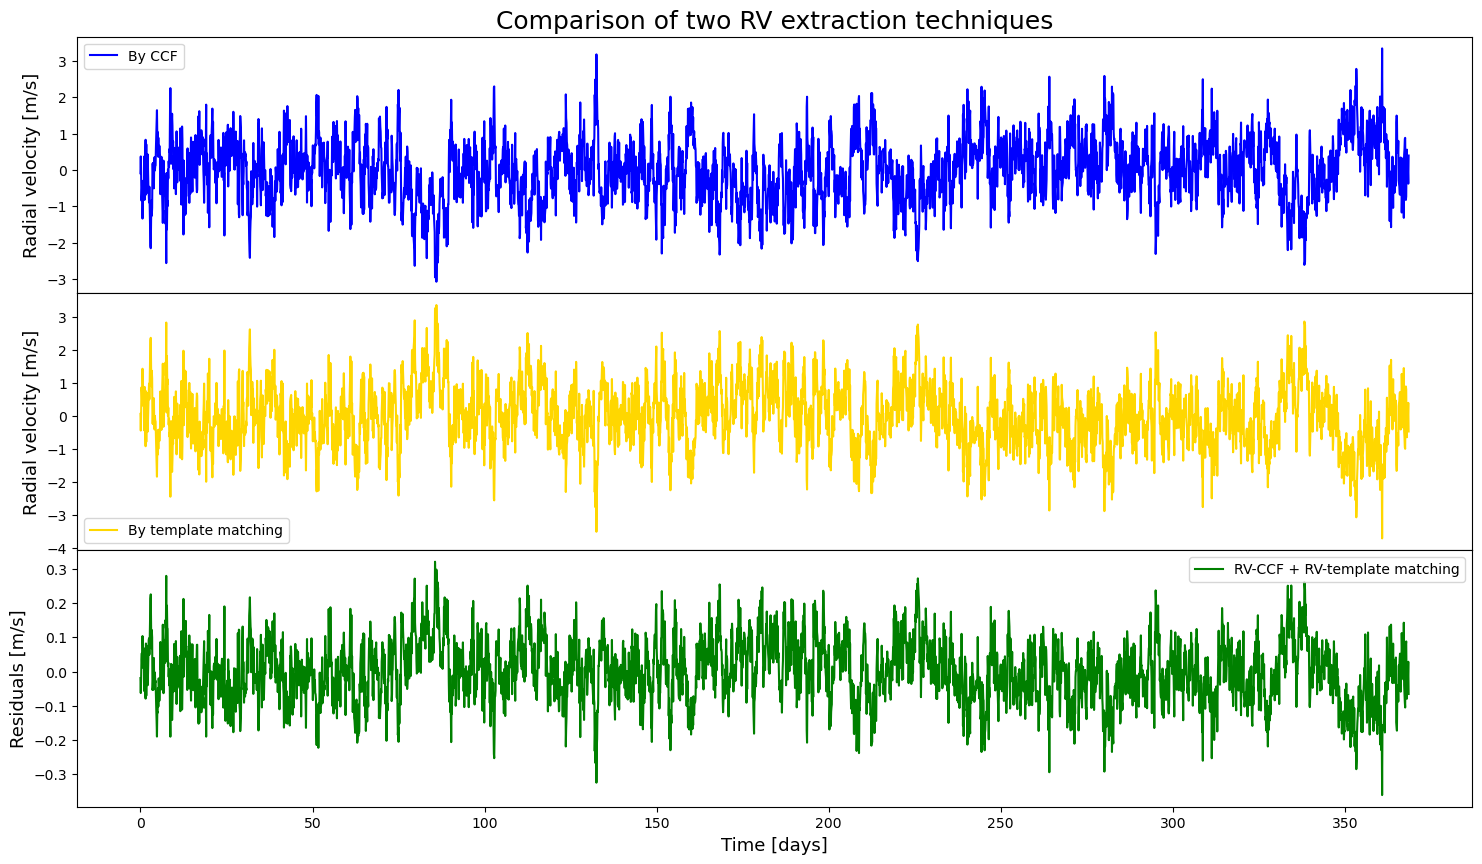

In [8]:
# plot RV
fig, axs = plt.subplots(3, 1, figsize=(18, 10), sharex=True)

axs[0].plot(times, rv_ccf, color='blue', label='By CCF')
axs[0].set_title('Comparison of two RV extraction techniques', size=18)
axs[0].set_ylabel('Radial velocity [m/s]', size=13)
#axs[0].set_xlim(0, 30)
axs[0].legend()

axs[1].plot(times, rv_tm, color='gold', label='By template matching')
axs[1].set_ylabel('Radial velocity [m/s]', size=13)
axs[1].legend()

axs[2].plot(times, rv_tm + rv_ccf, color='green', label='RV-CCF + RV-template matching')
axs[2].set_xlabel('Time [days]', size=13)
axs[2].set_ylabel('Residuals [m/s]', size=13)
axs[2].legend()

plt.subplots_adjust(hspace=0)
plt.show()

In [9]:
# get multiplicative factor
factor = rv_tm / rv_ccf
print(np.mean(factor), np.median(factor), np.std(factor))

-1.160555708708268 -1.1040211343759334 2.87991715422945


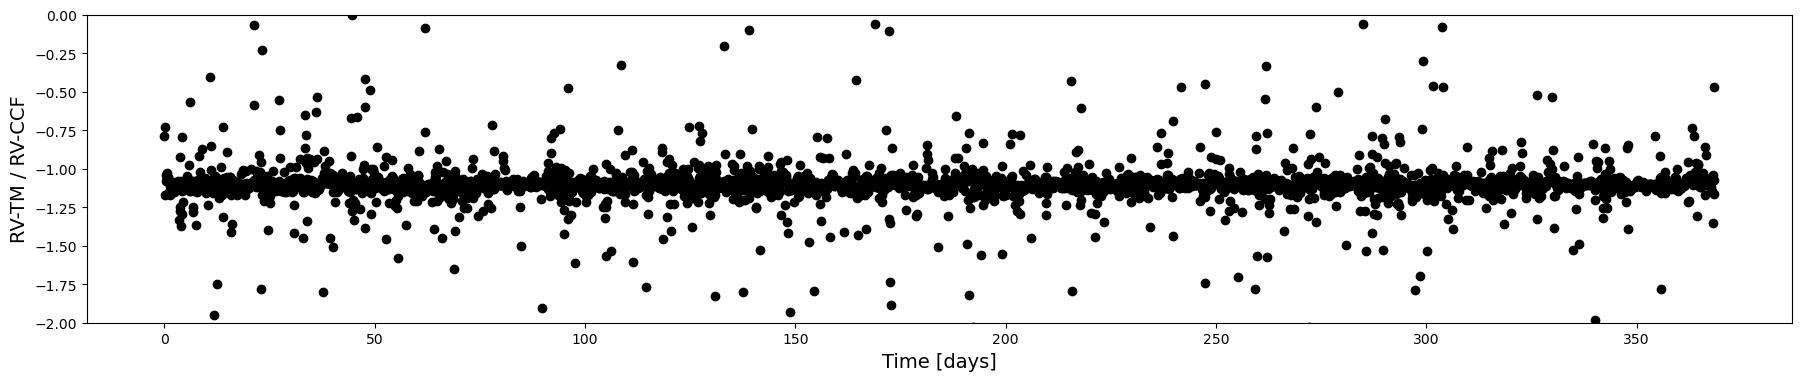

In [10]:
# multiplicative factor between RV-TM and RV-CCF over time
fig, ax = plt.subplots(figsize=(22, 4))
ax.plot(times, factor, 'ko')
ax.set_xlabel('Time [days]', size=14)
ax.set_ylabel('RV-TM / RV-CCF', size=14)
ax.set_ylim(-2, 0)
plt.show()

In [11]:
# try different values of C_0
list_C = np.logspace(1, 4, 4)
RV_tm = []  # RV over time for each value of C_0
for i in list_C:  # iterate over values of C_0
    v = []
    for k in range(len(data_spectra)):  # iterate over spectra
        v.append(t.calculate_rv(wl, mean_spec, data_spectra[k], i))  # save RV of each spectrum
    v = np.array(v)
    RV_tm.append(v)
RV_tm = np.array(RV_tm)

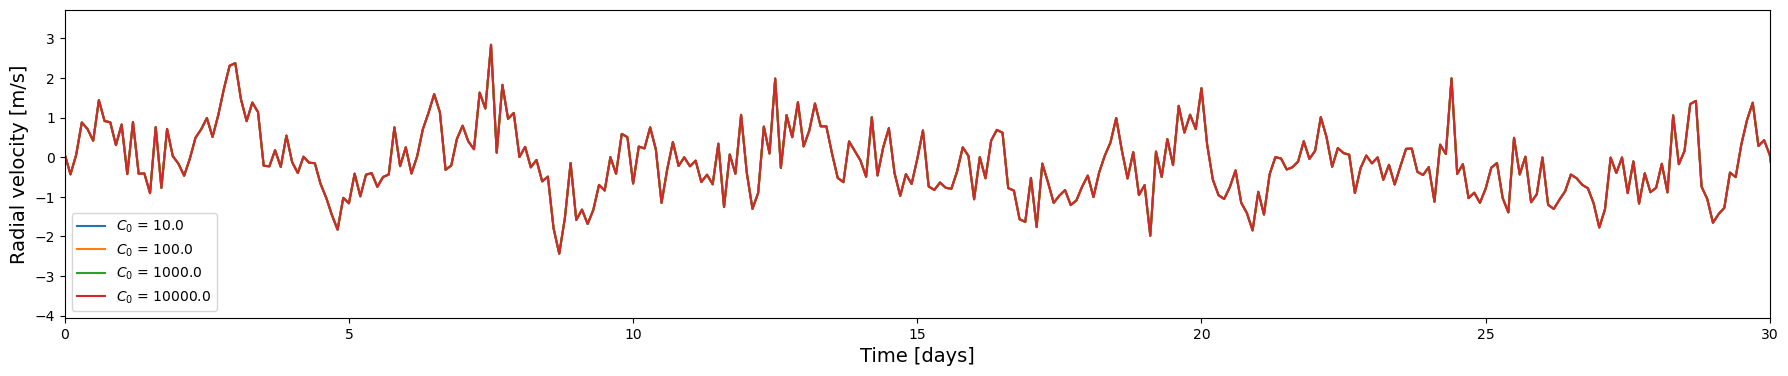

In [12]:
fig, ax = plt.subplots(figsize=(22, 4))
for i in range(len(RV_tm)):
    ax.plot(times, RV_tm[i], label=r'$C_0$ = '+str(list_C[i]))
    ax.set_xlabel('Time [days]', size=14)
    ax.set_ylabel('Radial velocity [m/s]', size=14)
    ax.legend()
ax.set_xlim(0, 30)
plt.show()

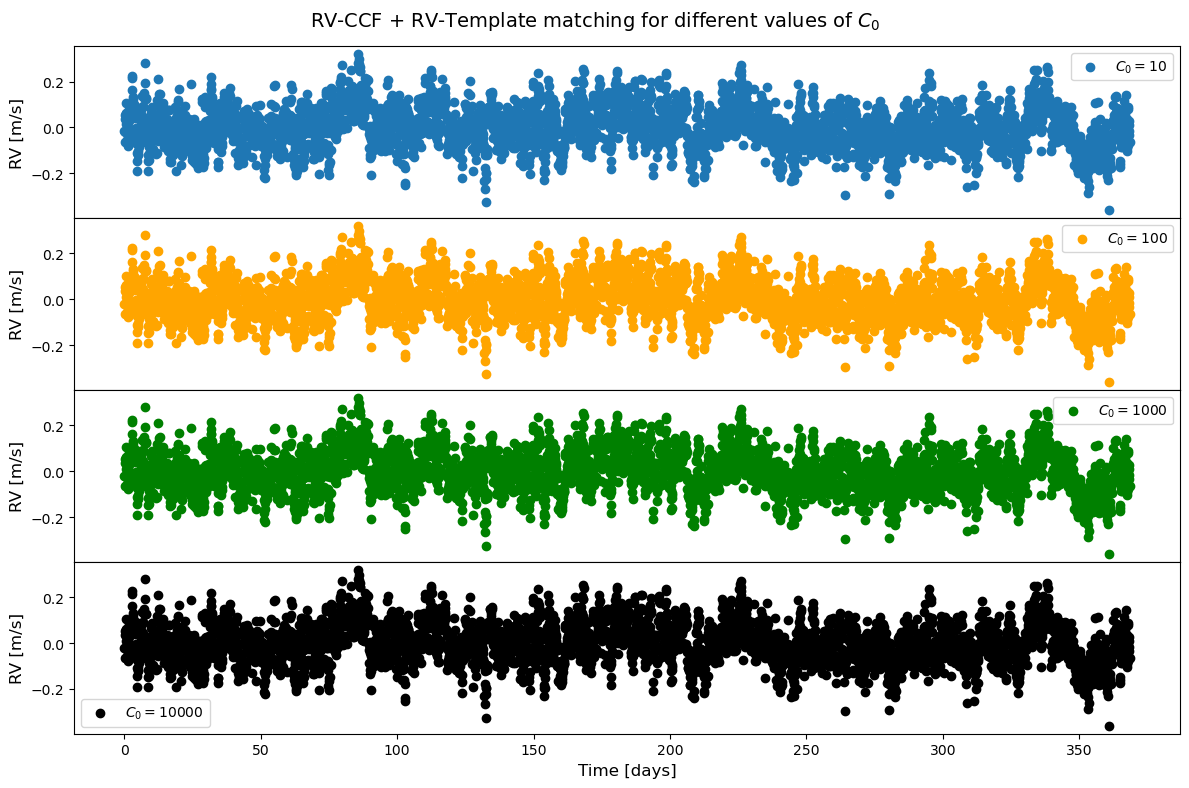

In [13]:
# RV-CCF + RV-Template matching for different values of C_0
fig, axs = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
fig.suptitle(r'RV-CCF + RV-Template matching for different values of $C_0$', size=14)
axs[0].scatter(times, rv_ccf + RV_tm[0], label=r'$C_0=10$')
axs[0].set_ylabel('RV [m/s]', size=12)
axs[0].legend()

axs[1].scatter(times, rv_ccf + RV_tm[1], color='orange', label=r'$C_0=100$')
axs[1].set_ylabel('RV [m/s]', size=12)
axs[1].legend()

axs[2].scatter(times, rv_ccf + RV_tm[2], color='green', label=r'$C_0=1000$')
axs[2].set_ylabel('RV [m/s]', size=12)
axs[2].legend()

axs[3].scatter(times, rv_ccf + RV_tm[3], color='black', label=r'$C_0=10000$')
axs[3].set_xlabel('Time [days]', size=12)
axs[3].set_ylabel('RV [m/s]', size=12)
axs[3].legend()

fig.tight_layout()
plt.subplots_adjust(hspace=0)
plt.show()

In [14]:
print(np.median(rv_ccf + RV_tm[0]))
print(np.median(rv_ccf + RV_tm[1]))
print(np.median(rv_ccf + RV_tm[2]))
print(np.median(rv_ccf + RV_tm[3]))

-0.0013983237408657125
-0.0013364446349801475
-0.001315802652296319
-0.001309210782564768


In [15]:
np.median(rv_ccf + RV_tm[3]) > np.median(rv_ccf + RV_tm[0])

np.True_

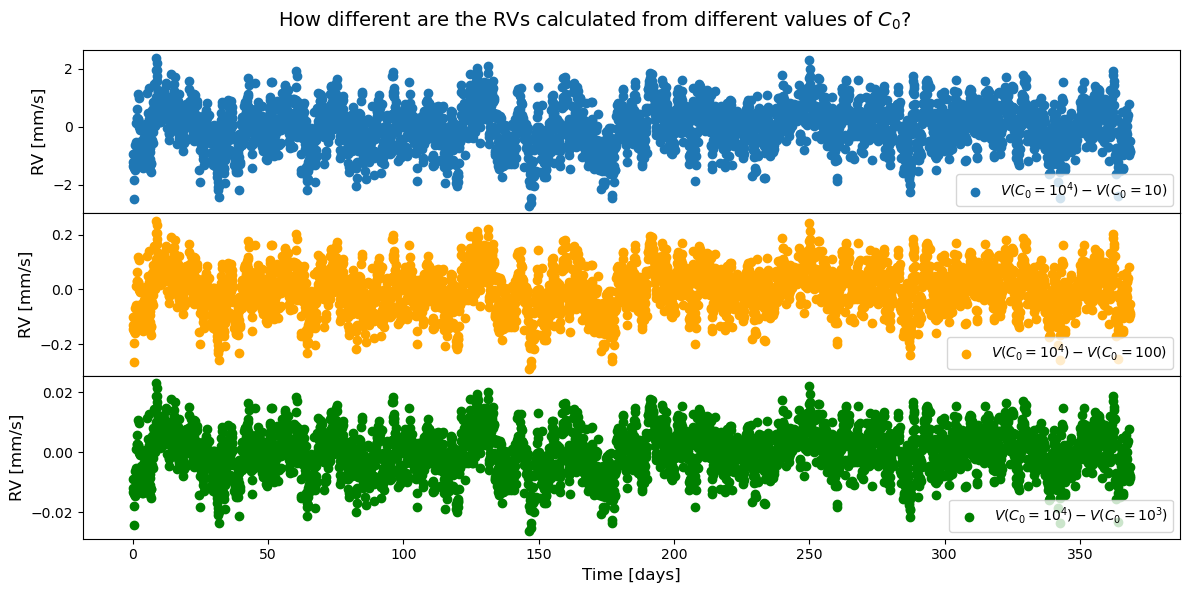

In [16]:
# residuals: the differences between RVs calculated with different values of C_0 are small, of the order of mm/s or smaller
fig, axs = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
fig.suptitle(r'How different are the RVs calculated from different values of $C_0$?', size=14)
axs[0].scatter(times, 1000*(RV_tm[3] - RV_tm[0]), label=r'$V(C_0=10^4) - V(C_0=10)$')
axs[0].set_ylabel('RV [mm/s]', size=12)
axs[0].legend()

axs[1].scatter(times, 1000*(RV_tm[3] - RV_tm[1]), color='orange', label=r'$V(C_0=10^4) - V(C_0=100)$')
axs[1].set_ylabel('RV [mm/s]', size=12)
axs[1].legend()

axs[2].scatter(times, 1000*(RV_tm[3] - RV_tm[2]), color='green', label=r'$V(C_0=10^4) - V(C_0=10^3)$')
axs[2].set_ylabel('RV [mm/s]', size=12)
axs[2].set_xlabel('Time [days]', size=12)
axs[2].legend()

fig.tight_layout()
plt.subplots_adjust(hspace=0)
plt.show()

## Calculate RV by CCF

In [17]:
#lambda_ref = wl[np.argmin(mean_spec)]  # pick a reference wavelength: I choose the one corresponding to the minimum flux of the reference spectrum
#delta_lambda = wl - lambda_ref  # Angstrom
#vels = c * delta_lambda / wl  # m / s
delta_vel = np.linspace(-5, 5, 201)  # define RV grid
lambda_vr = np.array([t.calculate_lambda_vr(wl, v) for v in delta_vel])  # wavelength grid for each v

In [18]:
# interpolate flux over lambda_vr to fit the originl wavelength grid (wl)
shifted_mask = []  # list of shifted masks, corresponding to each delta_vel
for wl_grid in lambda_vr:  # iterate over wavelength grids
    shifted_mask.append(np.interp(wl, wl_grid, mean_spec))
shifted_mask = np.array(shifted_mask)

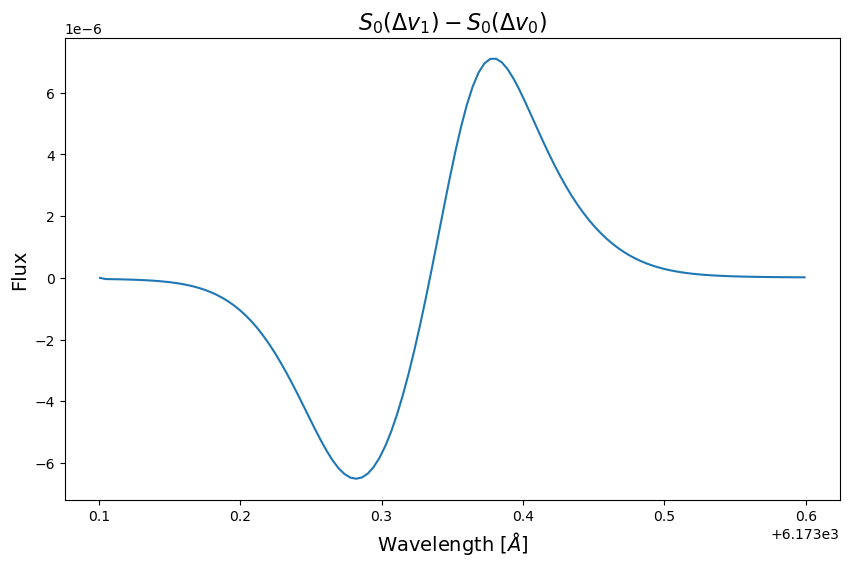

In [19]:
# are the shifted masks different from each other?
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(wl, shifted_mask[1] - shifted_mask[0])
ax.set_title(r'$S_0(\Delta v_1) - S_0(\Delta v_0)$', size=16)
ax.set_xlabel(r'Wavelength [$\AA$]', size=14)
ax.set_ylabel('Flux', size=14)
plt.show()

In [20]:
# calculate CCF between each measured spectrum and the reference spectrum
ccf = []
for j in tqdm(range(len(data_spectra))):  # iterate over measured (simulated) spectra
    ccf.append(np.array(
        [sum(t.cross_correlate(data_spectra[j], shifted_mask[i])) for i in range(len(delta_vel))]  # CCF
        ))
ccf = np.array(ccf)  # 2-dimensional array, each element is a list of CCFs between an observed spectrum and all the shifted masks

100%|██████████| 3686/3686 [00:12<00:00, 305.01it/s]


In [21]:
# fit a gaussian to each CCF
params = []
models = []
for i in tqdm(range(len(ccf))):  # iterate over CCF indices
    params_i, _ = curve_fit(t.gaussian, delta_vel, ccf[i], p0=[max(ccf[i])- min(ccf[i]), 0, np.std(delta_vel), np.max(ccf[i])])  # fit a gaussian to the CCF and save the parameters
    model_i = t.gaussian(delta_vel, params_i[0], params_i[1], params_i[2], params_i[3])  # calculate the model using the obtained parameters
    params.append(params_i)  # save parameters
    models.append(model_i)  # save model
params = np.array(params)
models = np.array(models)
mean_vels = params[:, 1]  # recover the position of the peak of each gaussian

  0%|          | 0/3686 [00:00<?, ?it/s]/tmp/ipykernel_3335/2715889321.py:5: OptimizeWarning: Covariance of the parameters could not be estimated
  params_i, _ = curve_fit(t.gaussian, delta_vel, ccf[i], p0=[max(ccf[i])- min(ccf[i]), 0, np.std(delta_vel), np.max(ccf[i])])  # fit a gaussian to the CCF and save the parameters
100%|██████████| 3686/3686 [00:04<00:00, 793.79it/s]


In [22]:
np.mean(delta_vel), np.std(delta_vel)

(np.float64(1.414015394547463e-16), np.float64(2.9011491975882016))

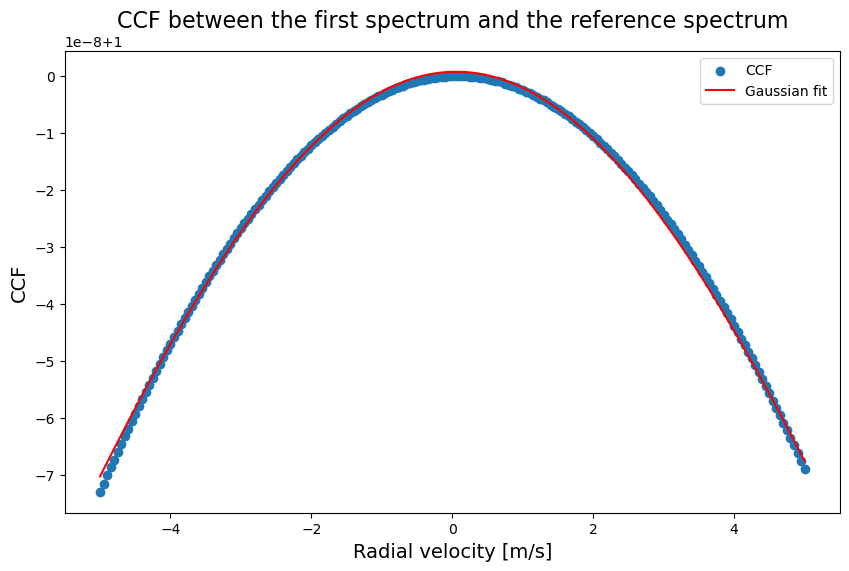

In [23]:
# plot example
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(delta_vel, ccf[0], label='CCF')
ax.plot(delta_vel, models[0], color='r', label='Gaussian fit')
ax.set_title('CCF between the first spectrum and the reference spectrum', size=16)
ax.set_xlabel('Radial velocity [m/s]', size=14)
ax.set_ylabel('CCF', size=14)
ax.legend()
#ax.set_xlim(-5, 5)
plt.show()

In [24]:
mean_vels

array([ 0.05454333, -0.44583731,  0.03279622, ..., -0.00169333,
        0.41512135, -0.47882986], shape=(3686,))

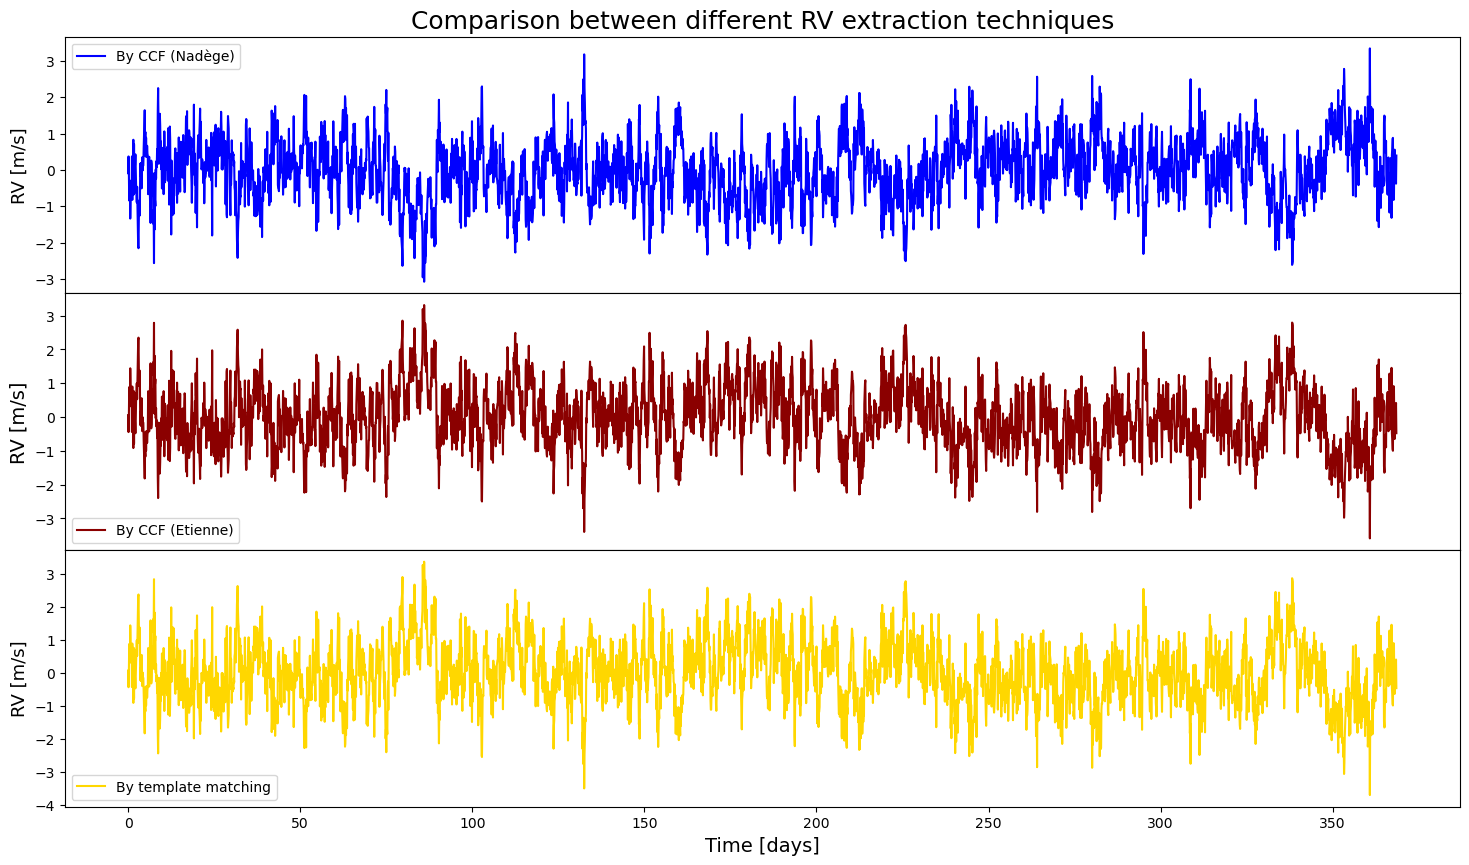

In [25]:
# plot RV
fig, axs = plt.subplots(3, 1, figsize=(18, 10), sharex=True)

axs[0].plot(times, rv_ccf, color='blue', label='By CCF (Nadège)')
axs[0].set_title('Comparison between different RV extraction techniques', size=18)
axs[0].set_ylabel('RV [m/s]', size=13)
#axs[0].set_xlim(0, 30)
axs[0].legend()

axs[1].plot(times, mean_vels, color='darkred', label='By CCF (Etienne)')
axs[1].set_ylabel('RV [m/s]', size=14)
axs[1].legend()

axs[2].plot(times, rv_tm, color='gold', label='By template matching')
axs[2].set_ylabel('RV [m/s]', size=13)
axs[2].legend()
axs[2].set_xlabel('Time [days]', size=14)

plt.subplots_adjust(hspace=0)
plt.show()

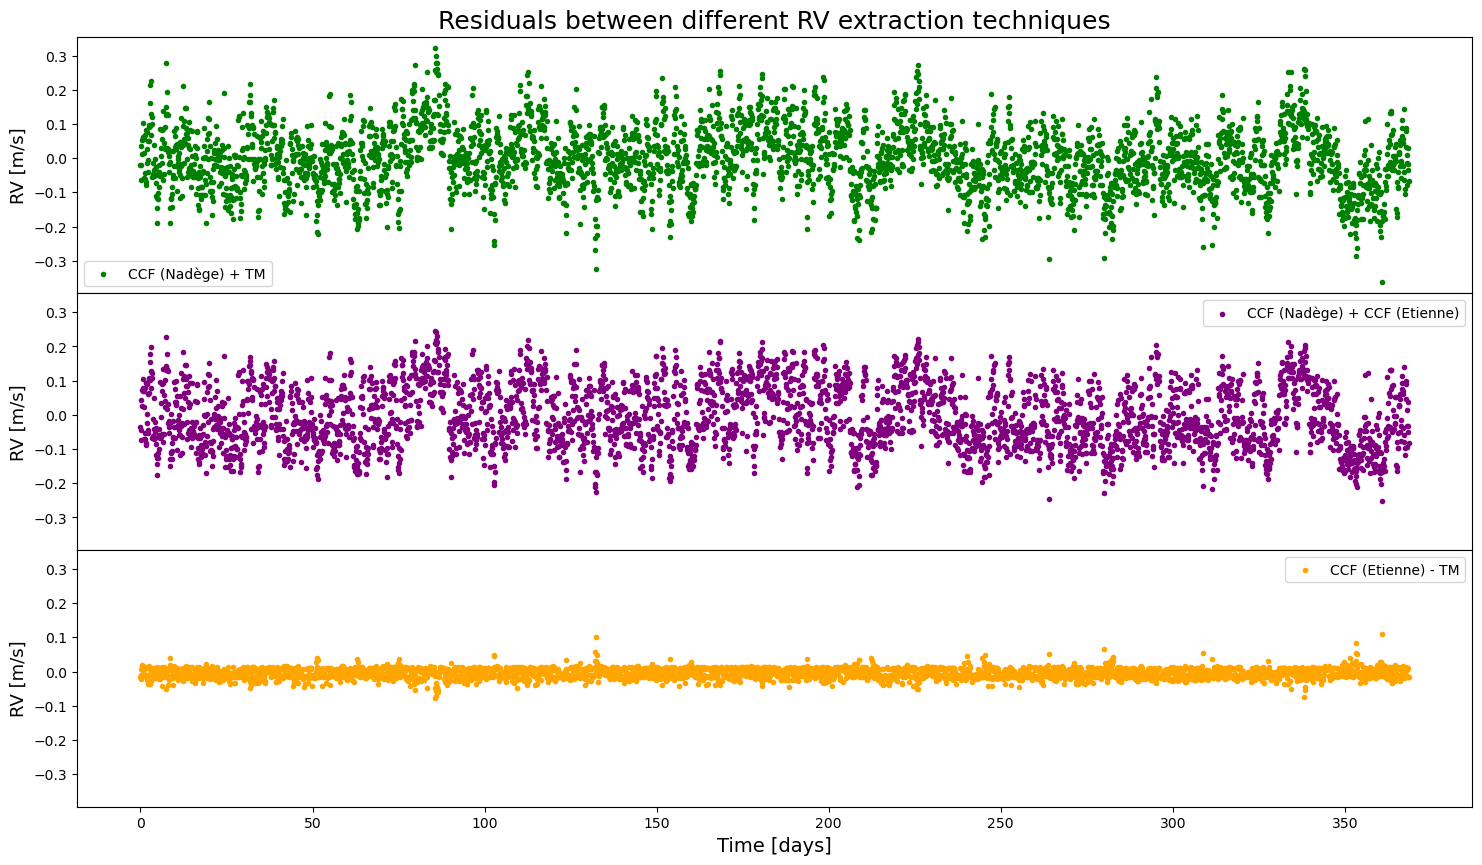

In [26]:
fig, axs = plt.subplots(3, 1, figsize=(18, 10), sharex=True, sharey=True)

axs[0].scatter(times, rv_ccf + rv_tm, marker='.', label='CCF (Nadège) + TM', color='g')
axs[0].set_title('Residuals between different RV extraction techniques', size=18)
axs[0].set_ylabel('RV [m/s]', size=13)
axs[0].legend()

axs[1].scatter(times, mean_vels + rv_ccf, marker='.', label='CCF (Nadège) + CCF (Etienne)', color='purple')
axs[1].set_ylabel('RV [m/s]', size=13)
axs[1].legend()

axs[2].scatter(times, mean_vels - rv_tm, marker='.', label='CCF (Etienne) - TM', color='orange')
axs[2].set_ylabel('RV [m/s]', size=13)
axs[2].legend()
axs[2].set_xlabel('Time [days]', size=14)

plt.subplots_adjust(hspace=0)
plt.show()

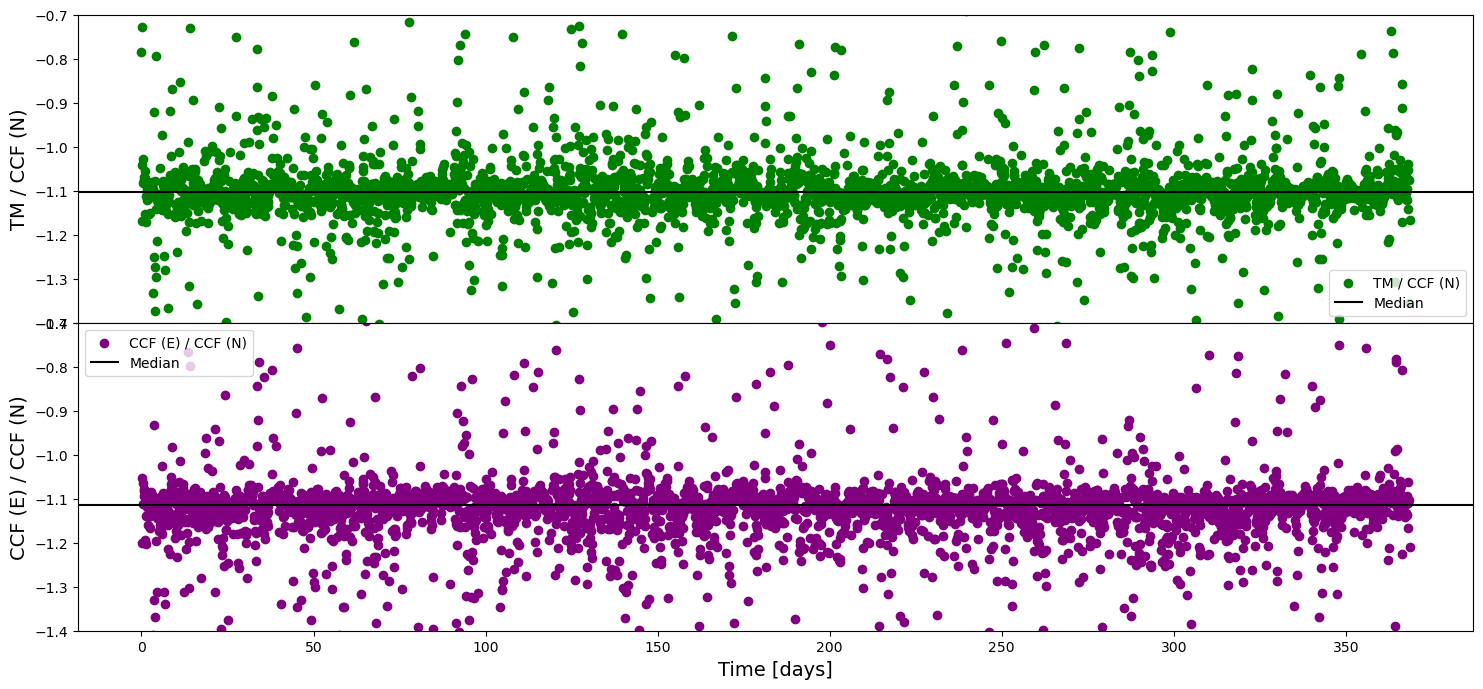

In [27]:
fig, axs = plt.subplots(2, 1, figsize=(18, 8), sharex=True)

axs[0].scatter(times, rv_tm / rv_ccf, color='green', label='TM / CCF (N)')
axs[0].axhline(np.median(rv_tm / rv_ccf), color='k', label='Median')
axs[0].set_xlabel('Time [days]', size=14)
axs[0].set_ylabel('TM / CCF (N)', size=14)
axs[0].set_ylim(-1.4, -.7)
axs[0].legend()

axs[1].scatter(times, mean_vels / rv_ccf, color='purple', label='CCF (E) / CCF (N)')
axs[1].axhline(np.median(mean_vels / rv_ccf), color='k', label='Median')
axs[1].set_xlabel('Time [days]', size=14)
axs[1].set_ylabel('CCF (E) / CCF (N)', size=14)
axs[1].set_ylim(-1.4, -.7)
axs[1].legend()

plt.subplots_adjust(hspace=0)
plt.show()

In [28]:
print(f'CCF (E) / CCF (N) median is {np.median(mean_vels / rv_ccf)}')
print(f'TM / CCF (N) median is {np.median(rv_tm / rv_ccf)}')

CCF (E) / CCF (N) median is -1.1141418679252126
TM / CCF (N) median is -1.1040211343759334


In [29]:
rv_ccfE = mean_vels

## RV Periodograms

In [141]:
# calculate RV periodograms
dt = times[1] - times[0]  # delta time in days
dt_sec = dt * 86400  # delta time in seconds
norm = dt_sec * len(times)  # same timestape for all techniques, so same normalization

# power spectrum
sp_ccf = np.fft.fft(rv_ccf) * dt_sec  # of RV calculated by CCF (Nadège)  [m]
power_ccf = np.abs(sp_ccf)**2 / norm  # [m^2/s]

sp_tm = np.fft.fft(rv_tm) * dt_sec  # of RV calculated by TM
power_tm = np.abs(sp_tm)**2 / norm

sp_ccfE = np.fft.fft(rv_ccfE) * dt_sec  # of RV calculated by CCF (Etienne)
power_ccfE = np.abs(sp_ccfE)**2 / norm

# calculate frequencies
freq_days = np.fft.fftfreq(len(rv_ccf), dt)  # frequency in days^-1 same for all power spectra
freq_hz   = freq_days / 86400  # frequency in Hz
mask = freq_days > 0

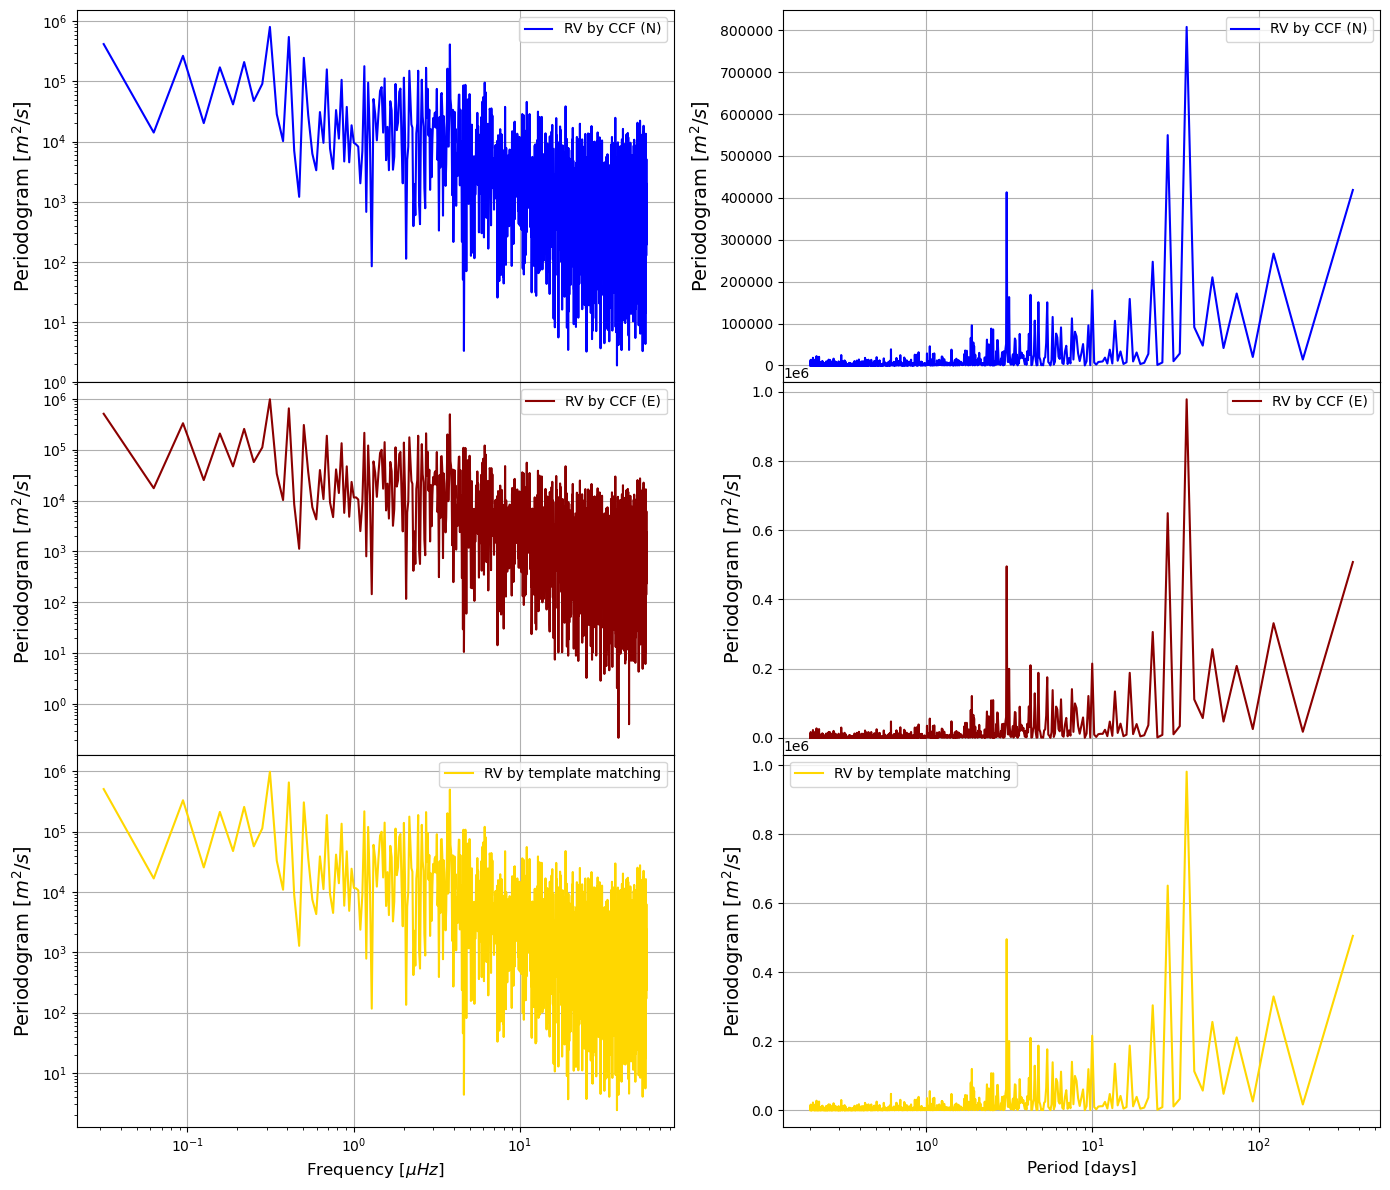

In [142]:
# plot RV periodograms
fig, axs = plt.subplots(3, 2, figsize=(14, 12), sharex='col')

# CCF (N)
# Frequency periodogram
axs[0][0].plot(freq_hz[mask] * 10**6, power_ccf[mask], color='blue', label='RV by CCF (N)')
axs[0][0].set_yscale('log')
axs[0][0].set_xscale('log')
axs[0][0].set_ylabel(r'Periodogram [$m^2/s$]', size=14)
axs[0][0].set_xlabel(r'Frequency [$\mu Hz$]', size=12)
axs[0][0].legend()
axs[0][0].grid()

# Periodogram
axs[0][1].plot(1 / freq_days[mask], power_ccf[mask], color='blue', label='RV by CCF (N)')
axs[0][1].set_xscale('log')
axs[0][1].set_xlabel('Period [days]', size=12)
axs[0][1].set_ylabel(r'Periodogram [$m^2/s$]', size=14)
axs[0][1].legend()
axs[0][1].grid()

# CCF (E)
# Frequency periodogram
axs[1][0].plot(freq_hz[mask] * 10**6, power_ccfE[mask], color='darkred', label='RV by CCF (E)')
axs[1][0].set_yscale('log')
axs[1][0].set_xscale('log')
axs[1][0].set_ylabel(r'Periodogram [$m^2/s$]', size=14)
axs[1][0].set_xlabel(r'Frequency [$\mu Hz$]', size=12)
axs[1][0].legend()
axs[1][0].grid()

# Periodogram
axs[1][1].plot(1 / freq_days[mask], power_ccfE[mask], color='darkred', label='RV by CCF (E)')
axs[1][1].set_xscale('log')
axs[1][1].set_xlabel('Period [days]', size=12)
axs[1][1].set_ylabel(r'Periodogram [$m^2/s$]', size=14)
axs[1][1].legend()
axs[1][1].grid()

# TM
# Frequency periodogram
axs[2][0].plot(freq_hz[mask] * 10**6, power_tm[mask], color='gold', label='RV by template matching')
axs[2][0].set_yscale('log')
axs[2][0].set_xscale('log')
axs[2][0].set_xlabel(r'Frequency [$\mu Hz$]', size=12)
axs[2][0].set_ylabel(r'Periodogram [$m^2/s$]', size=14)
axs[2][0].legend()
axs[2][0].grid()

# Periodogram
axs[2][1].plot(1 / freq_days[mask], power_tm[mask], color='gold', label='RV by template matching')
axs[2][1].set_xscale('log')
#axs[2][1].set_yscale('log')
axs[2][1].set_xlabel('Period [days]', size=12)
axs[2][1].set_ylabel(r'Periodogram [$m^2/s$]', size=14)
axs[2][1].legend()
axs[2][1].grid()

fig.tight_layout()
plt.subplots_adjust(hspace=0)
plt.show()

In [143]:
# split time series into chunks
n_chunks = 19
time_chunks = np.array_split(times, n_chunks)
ccf_chunks  = np.array_split(rv_ccf, n_chunks)
ccfE_chunks  = np.array_split(rv_ccfE, n_chunks)
tm_chunks   = np.array_split(rv_tm, n_chunks)
norm_mean = len(time_chunks[0]) * dt_sec  # normalization by total time (N * dt)

# do FT for each chunk
periodograms = {}
for i in range(n_chunks):  # iterate over chunk index
    # power spectrum
    sp_ccf_i = np.fft.fft(ccf_chunks[i]) * dt_sec  # apply FFT to the chunk i
    power_ccf_i = np.abs(sp_ccf_i)**2 / norm_mean  # calculate power

    sp_ccfE_i = np.fft.fft(ccfE_chunks[i]) * dt_sec
    power_ccfE_i = np.abs(sp_ccfE_i)**2 / norm_mean

    sp_tm_i = np.fft.fft(tm_chunks[i]) * dt_sec
    power_tm_i = np.abs(sp_tm_i)**2 / norm_mean

    # calculate frequencies
    freq_i = np.fft.fftfreq(len(ccf_chunks[i]), dt)  # dt stays the same, so the frequencies are the same for all periodograms [days^-1]
    mask_i = freq_i > 0  # same mask for all periodograms

    periodograms[i] = [sp_ccf_i, power_ccf_i, sp_ccfE_i, power_ccfE_i, sp_tm_i, power_tm_i, freq_i, mask_i]  # save periodogram elements

In [144]:
# mean power spectrum
mean_power_ccf = np.mean([periodograms[i][1] for i in range(n_chunks)], axis=0)  # from CCF (N)
mean_power_ccfE = np.mean([periodograms[i][3] for i in range(n_chunks)], axis=0)  # from CCF (E)
mean_power_tm = np.mean([periodograms[i][5] for i in range(n_chunks)], axis=0)  # from TM

# save important information
m       = periodograms[0][-1]  # mask (same for all)
f_days  = periodograms[0][-2][m] # frequency in days^-1 (same for all)
f_hz    = f_days / 86400 # frequency in Hz (same for all)
df      = f_days[1] - f_days[0]
df_hz   = f_hz[1] - f_hz[0]
psd_ccf = mean_power_ccf[m]
psd_ccfE = mean_power_ccfE[m]
psd_tm  = mean_power_tm[m]

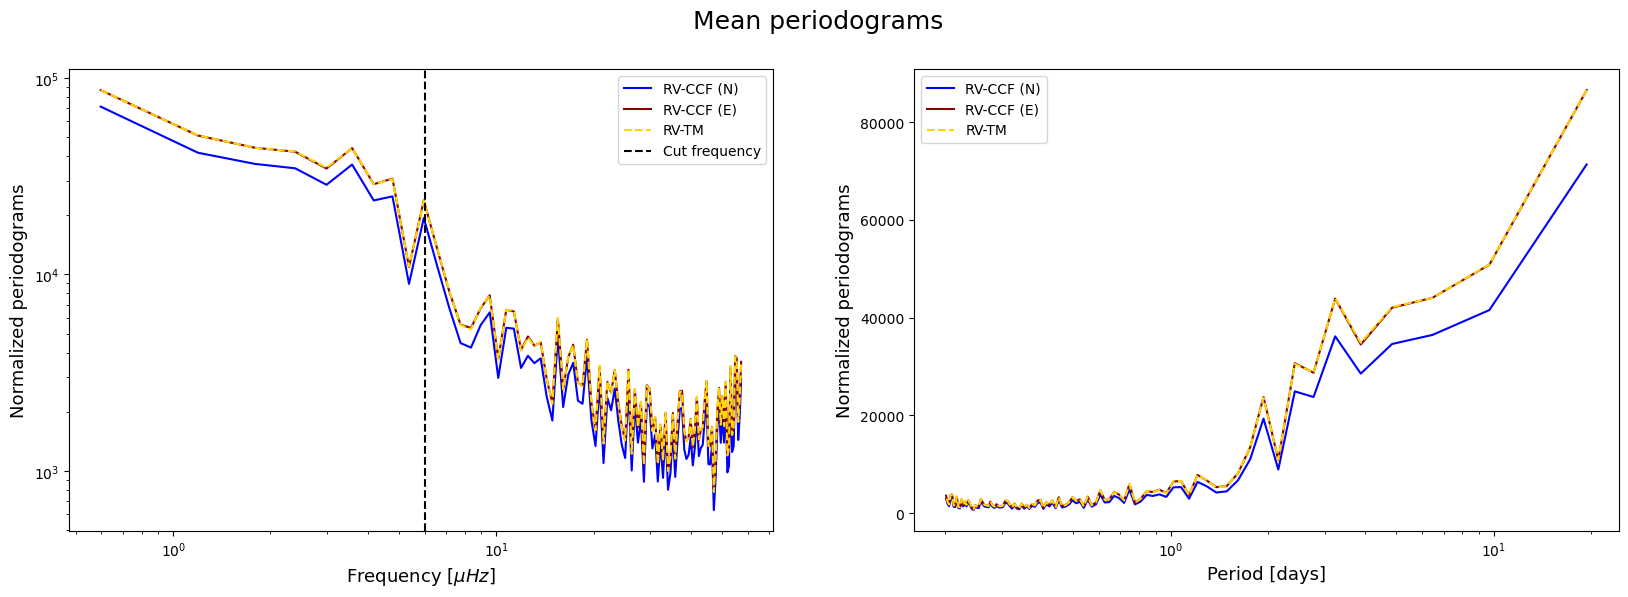

In [145]:
# put as a function of period too
fig, axs = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle('Mean periodograms', size=18)

axs[0].plot(f_hz * 10**6, psd_ccf, label='RV-CCF (N)', color='blue')
axs[0].plot(f_hz * 10**6, psd_ccfE, label='RV-CCF (E)', color='darkred')
axs[0].plot(f_hz * 10**6, psd_tm, label='RV-TM', color='gold', linestyle='--')
axs[0].axvline(6, color='k', linestyle='--', label='Cut frequency')
axs[0].set_xlabel(r'Frequency [$\mu Hz$]', size=13)
axs[0].set_ylabel('Normalized periodograms', size=13)
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].legend()

axs[1].plot(1 / f_days, psd_ccf, label='RV-CCF (N)', color='blue')
axs[1].plot(1 / f_days, psd_ccfE, label='RV-CCF (E)', color='darkred')
axs[1].plot(1 / f_days, psd_tm, label='RV-TM', color='gold', linestyle='--')
#axs[1].axvline(4.8, color='k', linestyle='--', label='Cut frequency')
axs[1].set_xlabel('Period [days]', size=13)
axs[1].set_ylabel('Normalized periodograms', size=13)
axs[1].set_xscale('log')
#axs[1].set_yscale('log')
axs[1].legend()

plt.show()

In [146]:
# fit Harvey function
# initial guess
p0 = [
    sum(psd_ccf) * df_hz,                 # a -> total power [m^2/s^2]
    4.8 / 10**6,                          # b -> turnover frequency from the plot above (where the power starts to decay) [Hz]
    2.0,                                  # c -> classical value, no units
    np.median(psd_ccf[f_hz * 10**6 > 20]) # d -> median of the noisy part from the plot above  [m^2/s]
]

# fit
params, _ = curve_fit(t.harvey, f_hz[1:], psd_ccf[1:], p0=p0)
a, b, c, d = params

In [147]:
# print results
print('Harvey fit to CCF periodogram:')
print(f'a={a:.2e} m^2/s^2 | b = {b:.2e} Hz | c = {round(c, 2)} | d = {round(d, 2)} m^2/s')

Harvey fit to CCF periodogram:
a=2.05e-01 m^2/s^2 | b = 4.84e-06 Hz | c = 3.62 | d = 1715.98 m^2/s


In [148]:
# calculate model from the parameters and SNR
model = t.harvey(f_hz, a, b, c, d)
snr = mean_power_ccf[m] / model

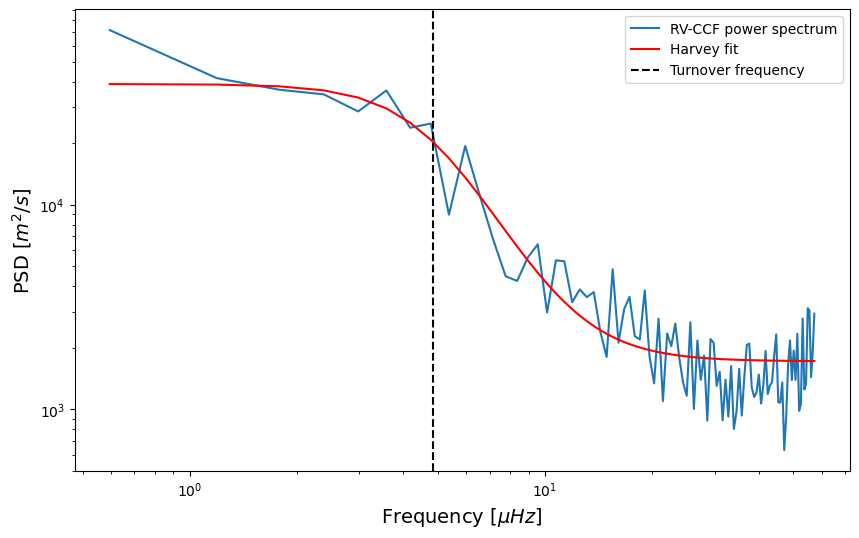

In [149]:
# plot fit
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f_hz * 10**6, mean_power_ccf[m], label='RV-CCF power spectrum')
ax.loglog(f_hz * 10**6, model, label='Harvey fit', color='red')
ax.axvline(b * 10**6, color='k', linestyle='--', label='Turnover frequency')
ax.set_xlabel(r'Frequency [$\mu Hz$]', size=14)
ax.set_ylabel(r'PSD [$m^2 / s$]', size=14)
ax.legend()
plt.show()

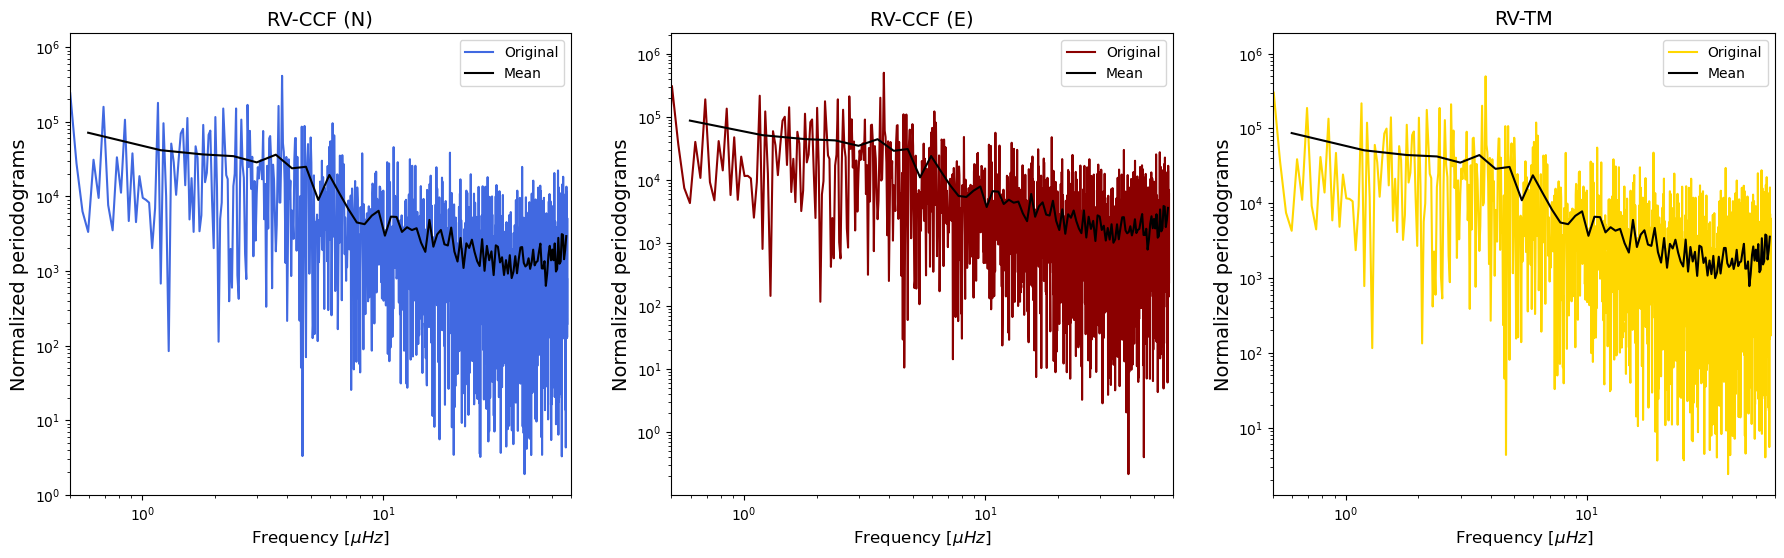

In [150]:
fig, axs = plt.subplots(1, 3, figsize=(22, 6))

# RV-CCF (N)
axs[0].plot(freq_hz[mask] * 10**6, power_ccf[mask], color='royalblue', label='Original')  # original periodogram
axs[0].plot(f_hz * 10**6, mean_power_ccf[m], color='k', label='Mean')  # mean periodogram
axs[0].set_yscale('log')
axs[0].set_xscale('log')
axs[0].set_title('RV-CCF (N)', size=14)
axs[0].set_xlabel(r'Frequency [$\mu Hz$]', size=12)
axs[0].set_ylabel('Normalized periodograms', size=14)
axs[0].set_xlim(.5, 60)
axs[0].legend()

# RV-CCF (E)
axs[1].plot(freq_hz[mask] * 10**6, power_ccfE[mask], color='darkred', label='Original')  # original periodogram
axs[1].plot(f_hz * 10**6, mean_power_ccfE[m], color='k', label='Mean')  # mean periodogram
axs[1].set_yscale('log')
axs[1].set_xscale('log')
axs[1].set_title('RV-CCF (E)', size=14)
axs[1].set_xlabel(r'Frequency [$\mu Hz$]', size=12)
axs[1].set_ylabel('Normalized periodograms', size=14)
axs[1].set_xlim(.5, 60)
axs[1].legend()

# RV-TM
axs[2].plot(freq_hz[mask] * 10**6, power_tm[mask], color='gold', label='Original')  # original periodogram
axs[2].plot(f_hz * 10**6, mean_power_tm[m], color='k', label='Mean')  # mean periodogram
axs[2].set_yscale('log')
axs[2].set_xscale('log')
axs[2].set_title('RV-TM', size=14)
axs[2].set_xlabel(r'Frequency [$\mu Hz$]', size=12)
axs[2].set_ylabel('Normalized periodograms', size=14)
axs[2].set_xlim(.5, 60)
axs[2].legend()

plt.show()

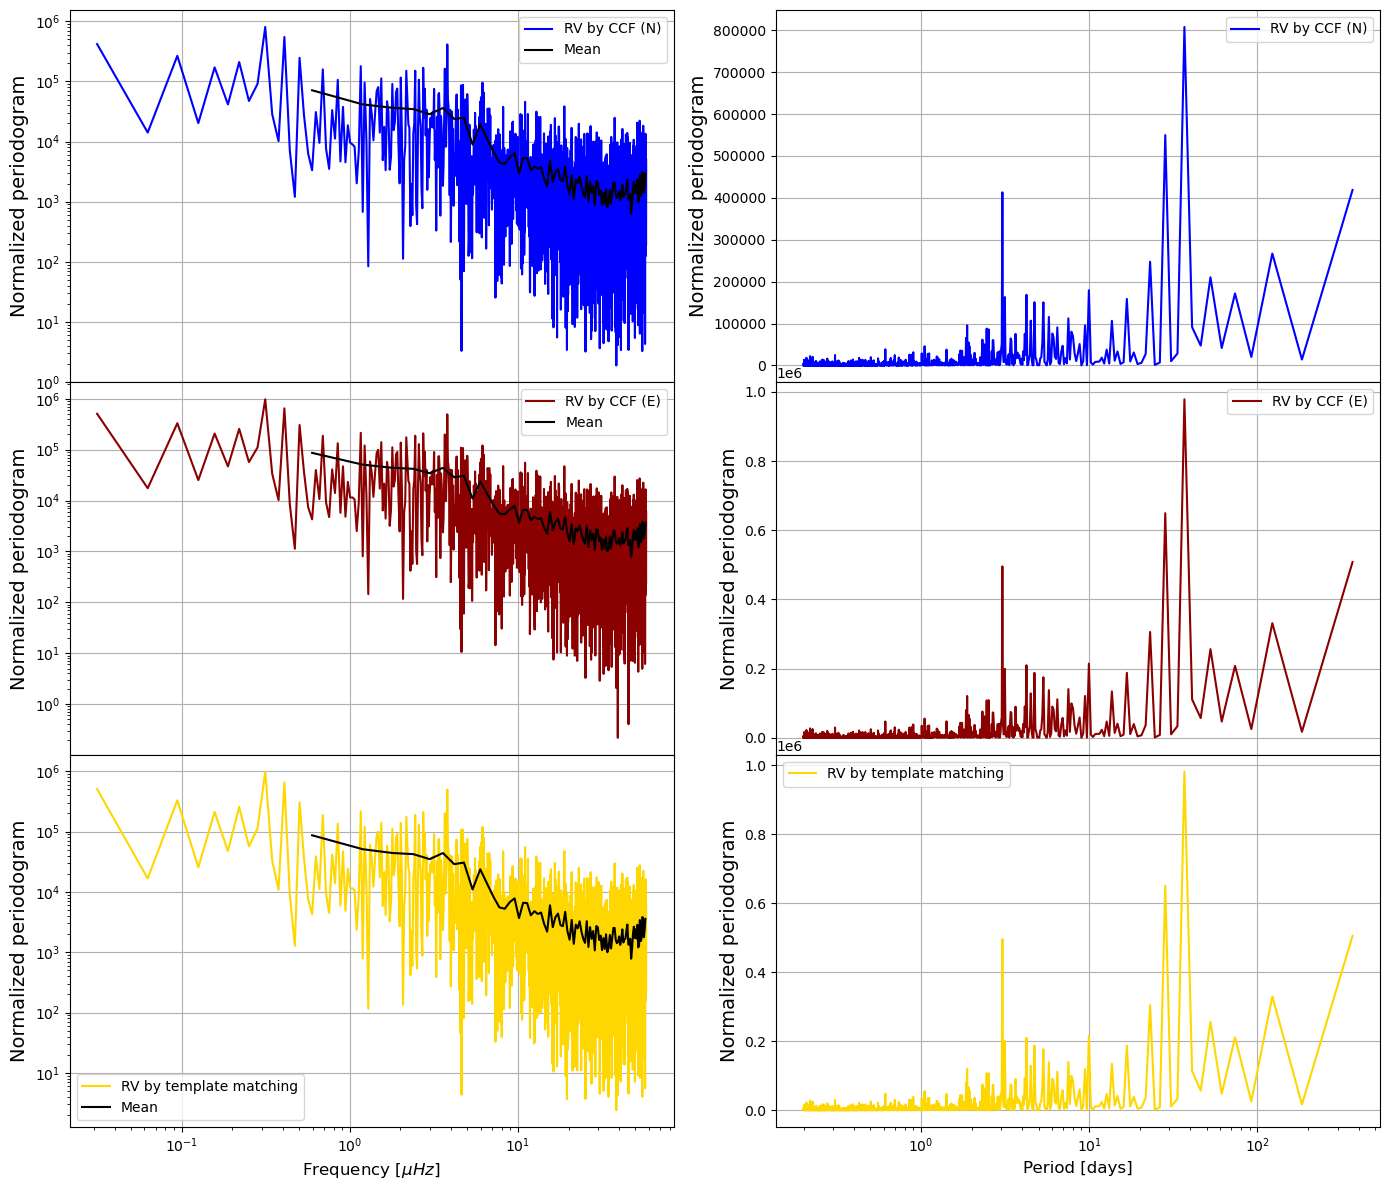

In [151]:
# plot RV periodograms
fig, axs = plt.subplots(3, 2, figsize=(14, 12), sharex='col')

# CCF (N)
# Frequency periodogram
axs[0][0].plot(freq_hz[mask] * 10**6, power_ccf[mask], color='blue', label='RV by CCF (N)')
axs[0][0].plot(f_hz * 10**6, mean_power_ccf[m], color='k', label='Mean')  # mean periodogram
axs[0][0].set_yscale('log')
axs[0][0].set_xscale('log')
axs[0][0].set_ylabel('Normalized periodogram', size=14)
axs[0][0].set_xlabel(r'Frequency [$\mu Hz$]', size=12)
axs[0][0].legend()
axs[0][0].grid()

# Periodogram
axs[0][1].plot(1 / freq_days[mask], power_ccf[mask], color='blue', label='RV by CCF (N)')
axs[0][1].set_xscale('log')
axs[0][1].set_xlabel('Period [days]', size=12)
axs[0][1].set_ylabel('Normalized periodogram', size=14)
axs[0][1].legend()
axs[0][1].grid()

# CCF (E)
# Frequency periodogram
axs[1][0].plot(freq_hz[mask] * 10**6, power_ccfE[mask], color='darkred', label='RV by CCF (E)')
axs[1][0].plot(f_hz * 10**6, mean_power_ccfE[m], color='k', label='Mean')  # mean periodogram
axs[1][0].set_yscale('log')
axs[1][0].set_xscale('log')
axs[1][0].set_ylabel('Normalized periodogram', size=14)
axs[1][0].set_xlabel(r'Frequency [$\mu Hz$]', size=12)
axs[1][0].legend()
axs[1][0].grid()

# Periodogram
axs[1][1].plot(1 / freq_days[mask], power_ccfE[mask], color='darkred', label='RV by CCF (E)')
axs[1][1].set_xscale('log')
axs[1][1].set_xlabel('Period [days]', size=12)
axs[1][1].set_ylabel('Normalized periodogram', size=14)
axs[1][1].legend()
axs[1][1].grid()

# TM
# Frequency periodogram
axs[2][0].plot(freq_hz[mask] * 10**6, power_tm[mask], color='gold', label='RV by template matching')
axs[2][0].plot(f_hz * 10**6, mean_power_tm[m], color='k', label='Mean')  # mean periodogram
axs[2][0].set_yscale('log')
axs[2][0].set_xscale('log')
axs[2][0].set_xlabel(r'Frequency [$\mu Hz$]', size=12)
axs[2][0].set_ylabel('Normalized periodogram', size=14)
axs[2][0].legend()
axs[2][0].grid()

# Periodogram
axs[2][1].plot(1 / freq_days[mask], power_tm[mask], color='gold', label='RV by template matching')
axs[2][1].set_xscale('log')
#axs[2][1].set_yscale('log')
axs[2][1].set_xlabel('Period [days]', size=12)
axs[2][1].set_ylabel('Normalized periodogram', size=14)
axs[2][1].legend()
axs[2][1].grid()

fig.tight_layout()
plt.subplots_adjust(hspace=0)
plt.show()

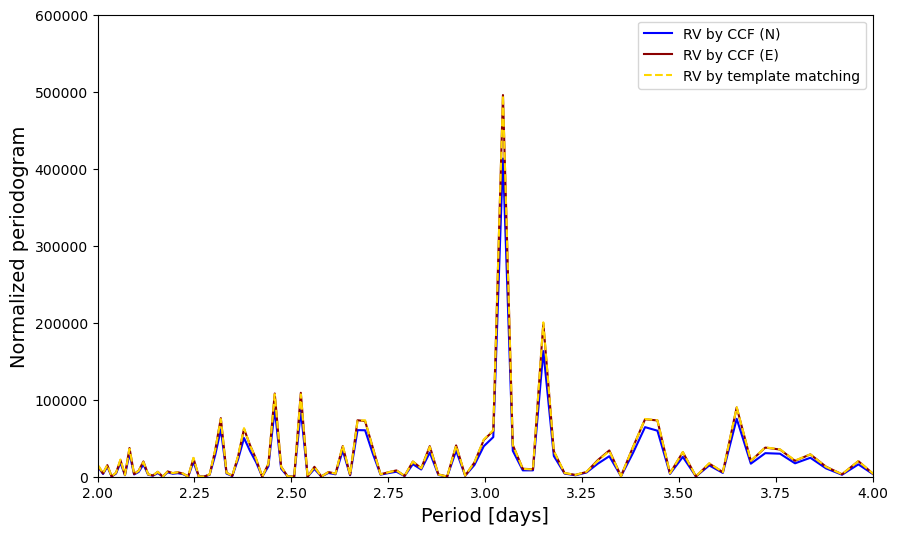

In [155]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(1 / freq_days[mask], power_ccf[mask], color='blue', label='RV by CCF (N)')
ax.plot(1 / freq_days[mask], power_ccfE[mask], color='darkred', label='RV by CCF (E)')
ax.plot(1 / freq_days[mask], power_tm[mask], color='gold', label='RV by template matching', linestyle='--')
ax.set_xlabel('Period [days]', size=14)
ax.set_ylabel('Normalized periodogram', size=14)
#ax.set_xscale('log')
ax.set_xlim(2, 4)
ax.set_ylim(-.1, .6e6)
ax.legend()

plt.show()

## Apply PCA

In [156]:
# corrected wavelength
lambda_corr = t.calculate_lambda_corr(wl, rv_ccf)

In [157]:
lambda_corr

array([[6173.10077184, 6173.10489084, 6173.10900884, ..., 6173.59086384,
        6173.59498184, 6173.59909984],
       [6173.10076235, 6173.10488135, 6173.10899935, ..., 6173.59085435,
        6173.59497235, 6173.59909035],
       [6173.10077156, 6173.10489056, 6173.10900856, ..., 6173.59086356,
        6173.59498156, 6173.59909956],
       ...,
       [6173.10077063, 6173.10488963, 6173.10900763, ..., 6173.59086263,
        6173.59498063, 6173.59909863],
       [6173.10077774, 6173.10489674, 6173.10901474, ..., 6173.59086974,
        6173.59498774, 6173.59910574],
       [6173.10076185, 6173.10488085, 6173.10899885, ..., 6173.59085385,
        6173.59497185, 6173.59908985]], shape=(3686, 122))

In [158]:
# interpolation to a common reference grid, as lambda_corr is different for each spectrum

resampled_flux = []

for wave, flux in zip(lambda_corr, data_spectra):  # iterate over wavelength, spectrum pairs
    interp_flux = np.interp(wl, wave, flux)  # interpolate the observed spectrum into the reference grid
    resampled_flux.append(interp_flux)  # save

spectra_matrix = np.array(resampled_flux)

In [159]:
# apply double centering to the spectra matrix
spectra_centered = t.double_centering(spectra_matrix)

In [160]:
# apply PCA to the centered spectra matrix
n_components = 20
pca_flux = PCA(n_components=n_components)  # create PCA object
pcs  = pca_flux.fit_transform(spectra_centered)  # fit the model with spectra_centered and apply the dimensionality reduction
var  = pca_flux.explained_variance_ratio_
print(f'Variance explained by the {n_components} components:', var)  # how much information (variance) can be attributed to each of the principal components

Variance explained by the 20 components: [5.84058761e-01 3.37753042e-01 7.44346744e-02 2.20807852e-03
 1.32671794e-03 1.44220570e-04 4.44046650e-05 1.26668343e-05
 8.10830686e-06 4.93663843e-06 1.60434188e-06 1.25245686e-06
 3.95939414e-07 1.24909119e-07 9.19352324e-08 7.64845279e-08
 1.59823771e-08 1.23543483e-08 1.14953082e-08 1.12403799e-08]


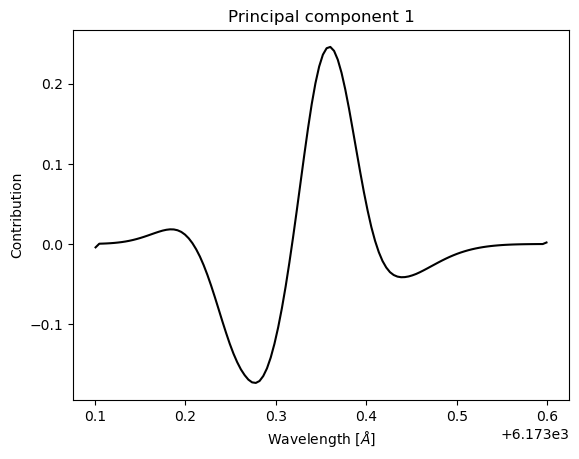

In [161]:
# plot loadings
# plot shows how much each wavelength value (feature) contributes to the variance of a PC
for i in range(1):  # put n_components instead of 1 to see all the plots
    plt.plot(wl, pca_flux.components_[i], color='k')
    plt.title(f'Principal component {i + 1}', size=12)
    plt.xlabel(r'Wavelength [$\AA$]')
    plt.ylabel('Contribution')
    plt.show()

In [162]:
# component significance
# multiple realizations allow to calculate error bars
n_realizations = 20
snr = 2000000
sigma = 1 / snr
mean_maxes = t.calculate_pca_significance(n_realizations, n_components, spectra_centered, sigma)  # list of max mean and std for each PC: [(max_avg_1, max_std_1), (max_avg_2, max_std_2), ..., (max_avg_n, max_std_n)]

100%|██████████| 20/20 [00:00<00:00, 32.35it/s]


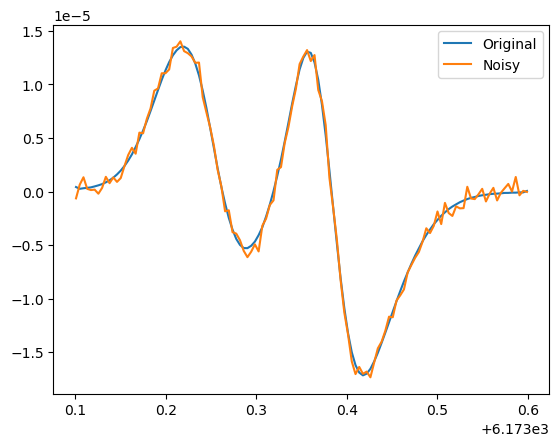

In [163]:
# show noise
spectra_noisy = spectra_centered + np.random.normal(0, sigma, len(wl))  # add gaussian noise to the original data
plt.plot(wl, spectra_centered[0], label='Original')
plt.plot(wl, spectra_noisy[0], label='Noisy')
plt.legend()
plt.show()

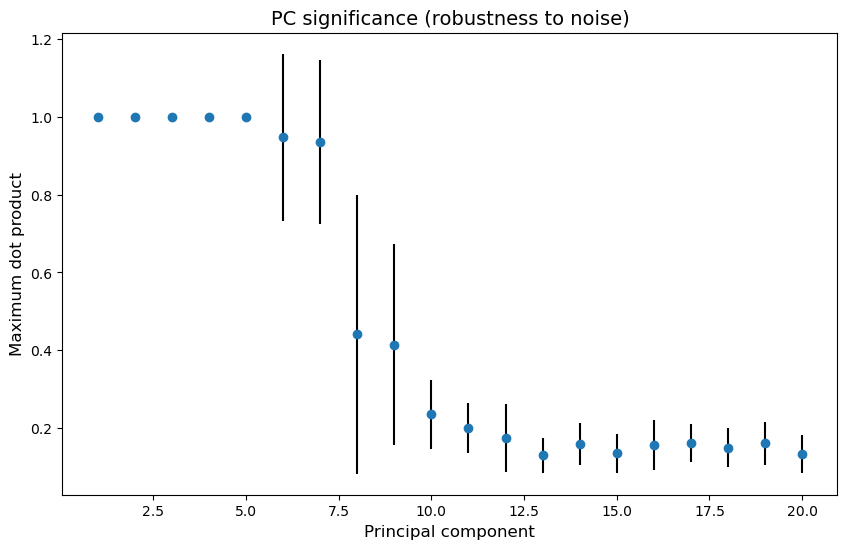

In [164]:
# plot component significance
fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(np.linspace(1, n_components, n_components), mean_maxes[:, 0], mean_maxes[:, 1], fmt='o', ecolor='k')
ax.set_title('PC significance (robustness to noise)', size=14)
ax.set_xlabel('Principal component', size=12)
ax.set_ylabel('Maximum dot product', size=12)
plt.show()

In [165]:
# calculate power spectrum
dt = times[1] - times[0]

# power spectrum
sp = np.array([np.fft.fft(pcs[:, i]) for i in range(n_components)])
power = np.abs(sp)**2

# calculate frequencies
# using fftfreq
freq = np.array([np.fft.fftfreq(pcs[:, i].shape[0], dt) for i in range(n_components)])

# by hand
N = len(times)
df = 1 / (N * dt)
freq2 = np.array([
    k * df if k < N//2 else (k - N) * df  # second half of the list goes negative
    for k in range(N)
])

In [166]:
N2 = 20
print([k if k < N2//2 else (k - N2) for k in range(N2)])

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, -10, -9, -8, -7, -6, -5, -4, -3, -2, -1]


In [167]:
min(freq[0]), max(freq[0])

(np.float64(-5.000000000000001), np.float64(4.9972870320130225))

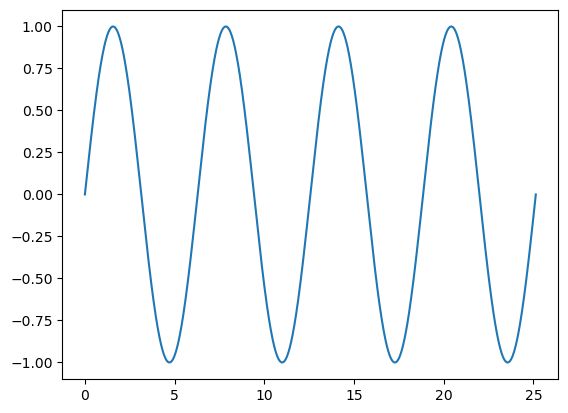

In [168]:
# check if FFT is working well
# define a function with a known frequency
theta = np.linspace(0, 8 * np.pi, 1000)
sin = np.sin(theta)
plt.plot(theta, sin)
plt.show()

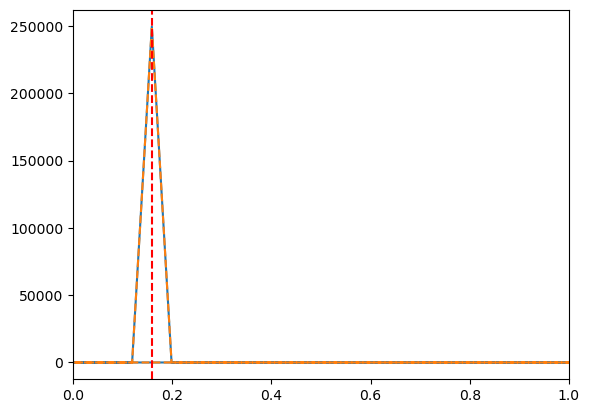

In [169]:
# check if FFT is working well
fft_sin = np.fft.fft(sin)
step = theta[1] - theta[0]
f_sin = np.fft.fftfreq(fft_sin.shape[0], step)
df_sin = 1 / (fft_sin.shape[0] * step)
f2 = np.arange(0, 1/step, df_sin)
f3 = np.array([
    k * df_sin if k < fft_sin.shape[0]//2 else (k - fft_sin.shape[0]) * df_sin  # second half of the list goes negative
    for k in range(fft_sin.shape[0])
])
plt.plot(f_sin, np.abs(fft_sin)**2)
plt.plot(f3, np.abs(fft_sin)**2, linestyle='--')
plt.axvline(1 / (2 * np.pi), color='red', linestyle='--')
plt.xlim(0, 1)
plt.show()

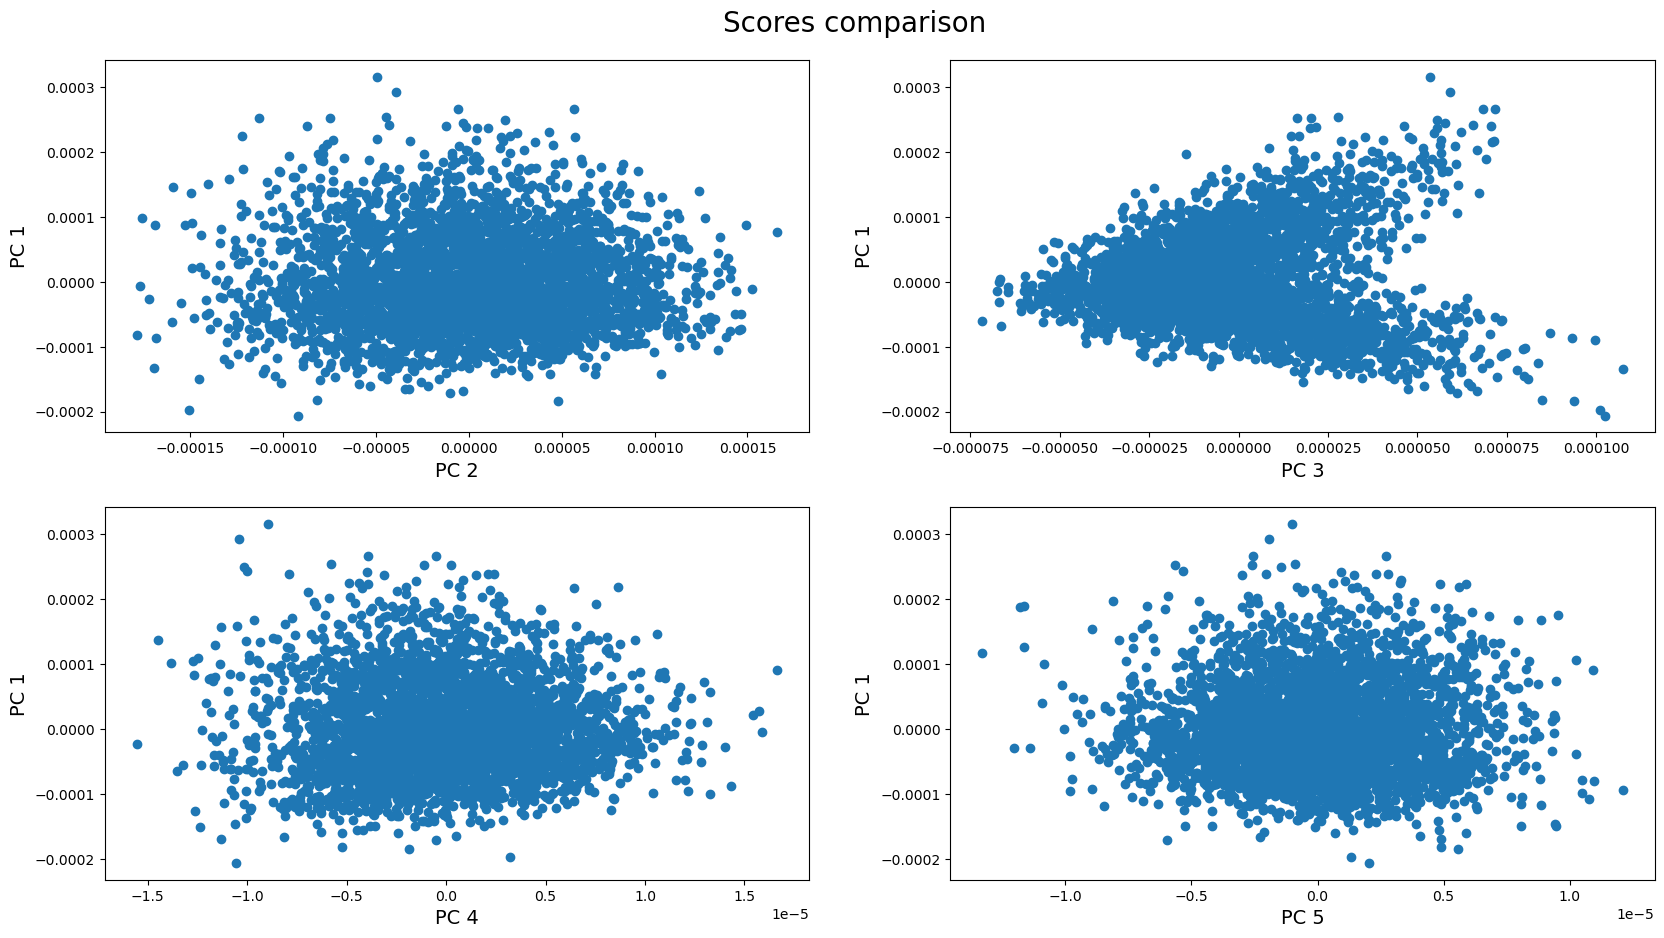

In [170]:
# RV (CCF) as a function of scores

rows = 2
cols = 2
fig, axs = plt.subplots(rows, cols, figsize=(20, 10))
fig.suptitle('Scores comparison', size=20)

r = -1
k = 0
for i in range(rows * cols):
    if i % cols == 0:
        r += 1  # advance to the next column
        k = 0  # reset row
    # RV as a function of scores
    axs[r][k].scatter(pcs[:, i+1], pcs[:, 0])
    axs[r][k].set_xlabel(f'PC {i+2}', size=14)
    axs[r][k].set_ylabel('PC 1', size=14)
    k += 1

plt.subplots_adjust(top=.93)
plt.show()

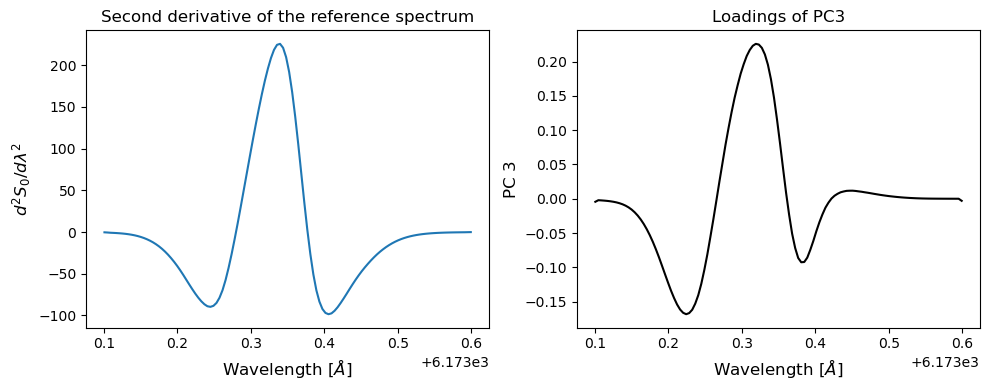

In [171]:
# second derivative vs PC3
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].plot(wl, d2_S0)
axs[0].set_title('Second derivative of the reference spectrum', size=12)
axs[0].set_xlabel(r'Wavelength [$\AA$]', size=12)
axs[0].set_ylabel(r'$d^2S_0 / d\lambda^2$', size=12)

axs[1].plot(wl, pca_flux.components_[2], color='k')
axs[1].set_title('Loadings of PC3', size=12)
axs[1].set_xlabel(r'Wavelength [$\AA$]', size=12)
axs[1].set_ylabel('PC 3', size=12)

fig.tight_layout()
plt.show()

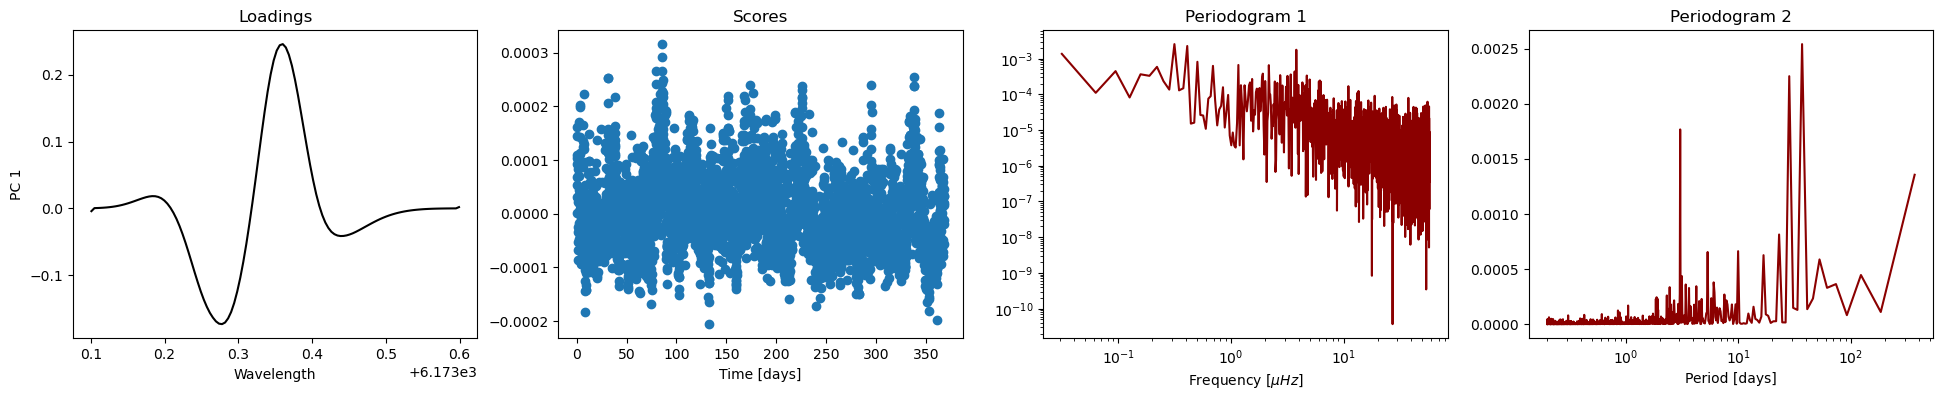

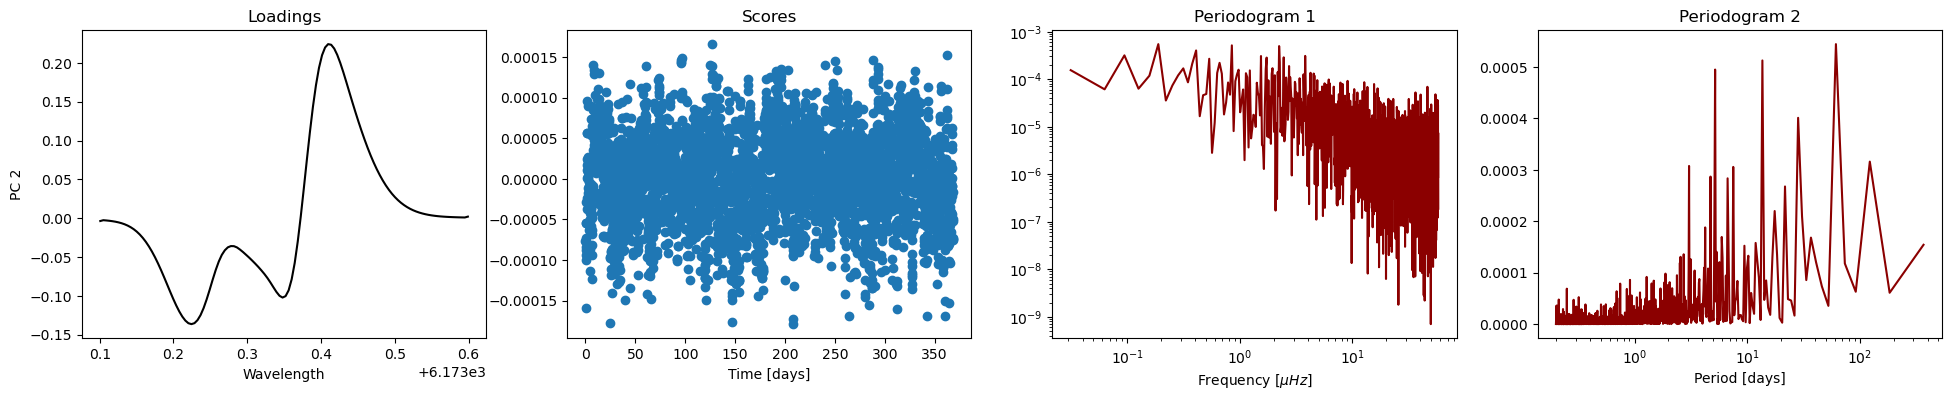

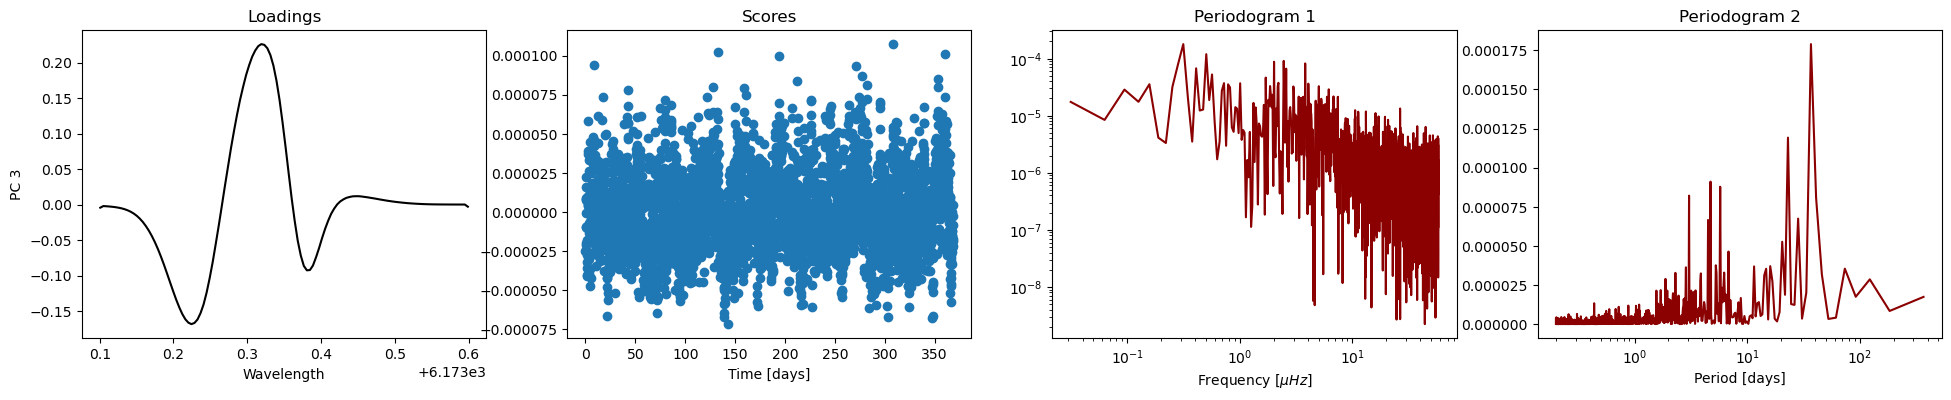

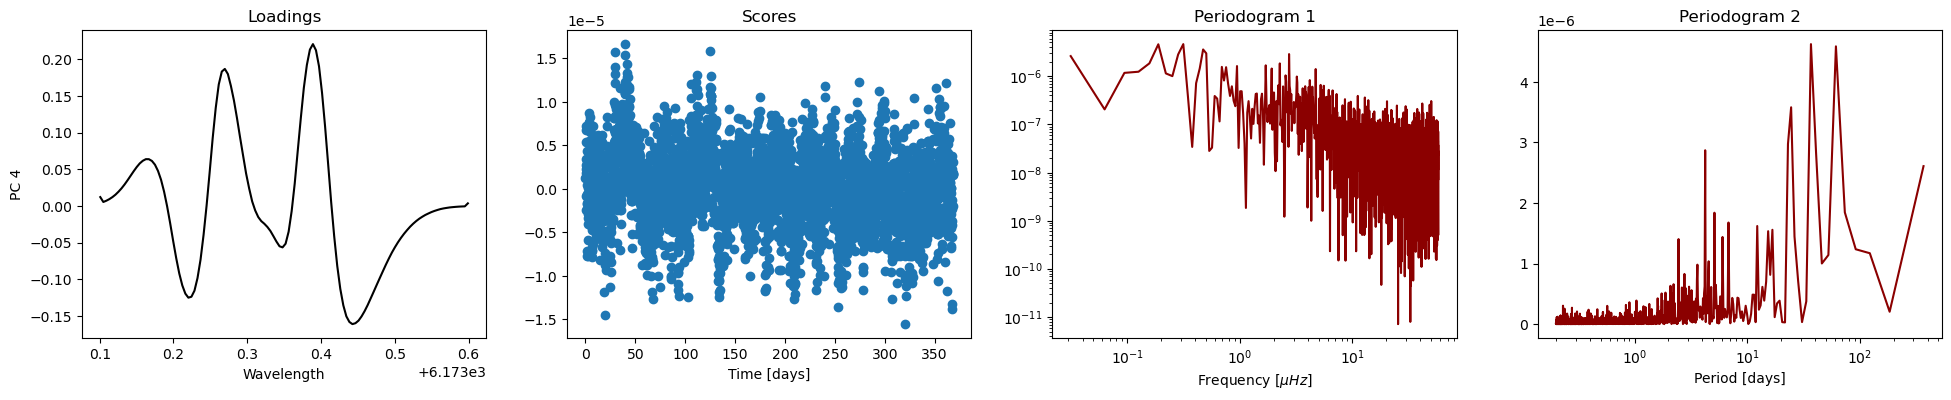

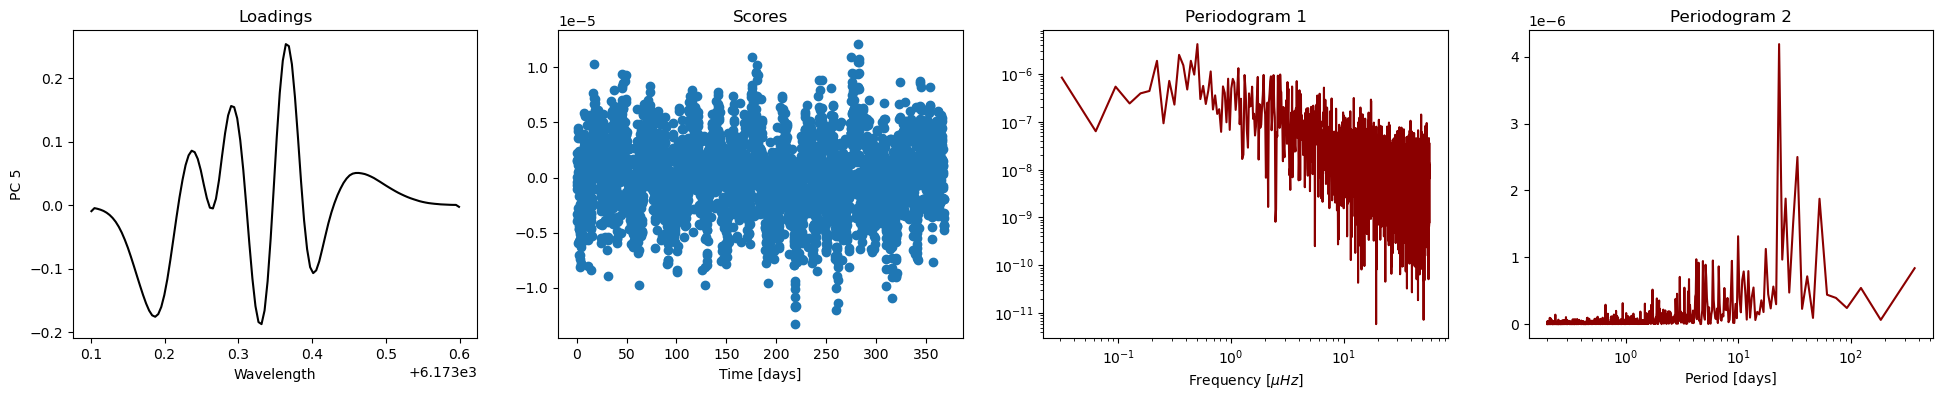

In [ ]:
# plot
for i in range(5):
    fig, axs = plt.subplots(1, 4, figsize=(24, 4))
    
    # Loadings
    axs[0].plot(wl, pca_flux.components_[i], color='k')
    axs[0].set_title('Loadings', size=12)
    axs[0].set_xlabel('Wavelength')
    axs[0].set_ylabel(f'PC {i + 1}')
    
    # Scores
    axs[1].scatter(times, pcs[:, i])
    axs[1].set_title('Scores', size=12)
    axs[1].set_xlabel('Time [days]')

    # Fourier power spectrum (frequency)
    mask = freq[i] > 0
    axs[2].plot(freq[i][mask] / 86400 * 10**6, power[i][mask], color='darkred')  # frequency divided by 86400 to pass from days^-1 to Hz, then multiplied by 10^6 to pass to microhertz
    axs[2].set_yscale('log')
    axs[2].set_xscale('log')
    axs[2].set_title('Periodogram 1', size=12)
    axs[2].set_xlabel(r'Frequency [$\mu Hz$]')
    
    # Fourier periodogram (period)
    axs[3].plot(1 / freq[i][mask], power[i][mask], color='darkred')
    #axs[3].set_yscale('log')
    axs[3].set_xscale('log')
    axs[3].set_title('Periodogram 2', size=12)
    axs[3].set_xlabel('Period [days]')

    plt.show()